<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/11_model_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB11 — Baselines Temporais, Modelos Supervisionados e Lead Time Inicial

## 1. Papel deste notebook no pipeline

Este notebook dá continuidade ao diagnóstico metodológico realizado no NB10.

O NB10 avaliou diferentes combinações de granularidade temporal, região BEFORE/AFTER, horizonte preditivo, persistência mínima e critério de limiar, promovendo ao NB11 apenas os cenários considerados metodologicamente defensáveis para modelagem supervisionada.

O NB11 revisado tem como objetivo avaliar se modelos supervisionados agregam valor em relação a regras temporais causais simples, preservando a ordem temporal dos dados, comparando diferentes conjuntos de features e produzindo escores para análise posterior de antecipabilidade e decisão sob incerteza.

Esta versão também corrige uma lacuna metodológica importante: os baselines deixam de ser avaliados apenas no corte fixo 80/20 e passam a ser avaliados também no TimeSeriesSplit, sob o mesmo protocolo principal usado para os modelos supervisionados.

## 2. Objetivo

Avaliar, nos cenários promovidos pelo NB10, se modelos supervisionados tabulares conseguem antecipar a entrada em estado crítico dentro de um horizonte futuro H, quando comparados a baselines temporais simples, causais e interpretáveis.

De forma específica, este notebook busca:

1. executar os cenários promovidos ao NB11 pelo NB10;
2. comparar baselines causais e modelos supervisionados sob TimeSeriesSplit;
3. manter o corte fixo 80/20 apenas como análise complementar;
4. comparar conjuntos de features brutas e temporais causais;
5. gerar escores brutos e calibrados para etapas posteriores;
6. estimar lead time bruto e taxa de episódios antecipados;
7. selecionar o melhor modelo tabular por F1 médio em TimeSeriesSplit;
8. registrar se há gatilho quantitativo para NB13;
9. registrar recomendação metodológica para execução defensiva de LSTM no NB13.

## 3. Entradas esperadas

Este notebook consome os seguintes artefatos produzidos pelo NB10:

- `10_scenario_advanced_to_nb11.json`
- `10_scenario_series_states.parquet`
- `10_scenario_episodes.parquet`
- `10_scenario_decisions.csv`

As features utilizadas devem ser numéricas, causalmente disponíveis até o instante t e alinhadas, quando possível, ao conjunto consolidado dos notebooks anteriores.

Não devem ser utilizadas como features colunas auxiliares de rótulo, estado, episódio, criticidade futura, identificadores temporais absolutos ou qualquer variável derivada de informação futura.

## 4. Cenários avaliados

São avaliados os cenários classificados pelo NB10 como `advance_to_nb11`.

Dois cenários merecem destaque interpretativo:

- `W5_K24_H12_P1_TRAIN_M2S`: candidato principal;
- `W5_K24_H12_P2_TRAIN_M2S`: candidato conservador.

O candidato principal preserva maior sensibilidade. O candidato conservador incorpora persistência mínima mais restritiva.

## 5. Conjuntos de features avaliados

Esta versão do NB11 avalia três conjuntos de features.

### 5.1 `raw_7`

Conjunto conservador de variáveis brutas e causalmente disponíveis:

- `fail_rate`
- `n_events`
- `n_failed`
- `n_machines`
- `n_collections`
- `event_FAIL_count`
- `event_LOST_count`

Esse conjunto testa se sinais simples e diretamente observáveis já são suficientes para antecipação.

### 5.2 `temporal_core`

Conjunto composto pelas variáveis brutas principais acrescidas de features temporais causais derivadas de `fail_rate`:

- `lag_1`
- `lag_2`
- `lag_3`
- `rolling_mean_1h`
- `rolling_std_1h`
- `pct_change`
- `zscore_expanding`

Esse conjunto testa a contribuição da engenharia temporal básica.

### 5.3 `temporal_full`

Conjunto mais amplo de variáveis numéricas causalmente disponíveis, incluindo métricas de volume, recursos, contagens por tipo de evento e features temporais.

Este conjunto se aproxima da lógica dos notebooks anteriores, mas permanece controlado por whitelist para reduzir risco de vazamento.

## 6. Baselines avaliados

São avaliados os seguintes baselines, tanto no corte fixo 80/20 quanto no TimeSeriesSplit.

### 6.1 Classe majoritária

Prediz sempre a classe 0. Serve como piso trivial e evidencia a insuficiência da acurácia isolada.

### 6.2 Baseline temporal ingênuo causal

Emite alerta se a taxa de falha observada na janela imediatamente anterior ultrapassar o limiar causal do cenário.

Este baseline não usa o estado `BEFORE`, pois esse estado é derivado da proximidade futura com episódios DURING e não estaria disponível em operação real.

### 6.3 Limiar rebaixado

Emite alerta se:

`fail_rate_t >= 0,5 × train_m2s`

Esta regra implementa a definição operacional do baseline por fração do limiar.

### 6.4 Z-score causal

Emite alerta se `zscore_expanding_t` ultrapassar um limiar estimado apenas no trecho de treino. Por padrão, usa-se o percentil 95 do z-score causal no treino.

## 7. Modelos supervisionados avaliados

São avaliados modelos tabulares com diferentes hipóteses de modelagem:

1. Regressão Logística com padronização e `class_weight="balanced"`;
2. Random Forest com tratamento explícito de desbalanceamento;
3. HistGradientBoosting com pesos amostrais balanceados.

A Regressão Logística preserva interpretabilidade e funciona como modelo linear de referência. Random Forest e HistGradientBoosting avaliam se relações não lineares agregam valor à tarefa.

## 8. Protocolo de validação

A validação principal é feita com `TimeSeriesSplit`, respeitando a ordem temporal dos dados.

O corte fixo 80/20 é mantido apenas como análise complementar, por comparabilidade com o artigo e para inspeção visual dos escores.

Não é utilizada validação cruzada aleatória comum, pois isso violaria a natureza temporal do problema.

## 9. Métricas

São calculadas as seguintes métricas:

- acurácia;
- precisão;
- recall;
- F1-score;
- ROC-AUC;
- Average Precision;
- Brier Score;
- matriz de confusão;
- falsos alertas por dia;
- lead time bruto;
- taxa de episódios antecipados.

O recall e o F1-score recebem maior atenção porque a tarefa é orientada à antecipação de estados críticos. Entretanto, falsos positivos também são registrados, pois serão relevantes para a análise de custo no NB14.

## 10. Calibração probabilística

O NB11 produz escores brutos e, quando viável, escores calibrados por Platt scaling.

A calibração é tratada como diagnóstico. Caso não melhore Brier Score e ECE de forma consistente, os escores devem ser interpretados como ranking relativo de risco temporal, e não como probabilidades operacionais diretamente acionáveis.

## 11. Lead time e taxa de episódios antecipados

O lead time bruto é calculado como a diferença entre o primeiro alerta emitido antes do início do episódio DURING e o início desse episódio.

Para evitar contaminação por alertas antigos, são considerados apenas alertas emitidos no intervalo imediatamente anterior ao episódio, limitado ao horizonte H do cenário.

Nesta versão, a taxa de episódios antecipados usa como denominador apenas episódios avaliáveis, isto é, episódios cujo intervalo anterior de H janelas possui escores disponíveis.

Alertas emitidos no início do DURING ou após seu início não contam como antecipação efetiva.

## 12. Critério de escolha do vencedor

O vencedor principal do NB11 é escolhido pelo maior F1 médio em TimeSeriesSplit, considerando simultaneamente:

- cenário;
- conjunto de features;
- modelo.

Recall, Average Precision, Brier Score, estabilidade temporal e interpretabilidade são registrados como critérios auxiliares.

O melhor modelo tabular será usado como referência para NB12 e, preferencialmente, para geração dos escores que alimentarão o NB14.

## 13. Relação com NB13/LSTM

A especificação original previa a execução do NB13 somente se o melhor modelo tabular do NB11 apresentasse:

- F1 médio em TimeSeriesSplit inferior a 0,45; ou
- desvio-padrão do F1 em TimeSeriesSplit superior a 0,29.

Nesta versão, esse gatilho quantitativo continua sendo registrado.

Entretanto, por orientação metodológica adicional, o NB13 passa a ser recomendado como experimento complementar defensivo, mesmo que o gatilho quantitativo não seja ativado. A justificativa é que, em problemas temporais, arquiteturas LSTM continuam sendo referência histórica e metodológica relevante, podendo ser questionada sua ausência por avaliadores ou revisores.

Assim, o NB13 deverá ser tratado como experimento complementar, enxuto e subordinado ao pipeline principal, e não como nova espinha dorsal da dissertação.

## 14. Artefatos produzidos

Este notebook produz:

- `11_metrics_tscv.csv`
- `11_metrics_fixed_split.csv`
- `11_metrics_summary.csv`
- `11_baselines_summary.csv`
- `11_feature_set_summary.csv`
- `11_calibration_summary.csv`
- `11_lead_time_summary.csv`
- `11_episode_anticipation.csv`
- `11_scores_raw.parquet`
- `11_scores_calibrated.parquet`
- `11_winner_model.json`
- `11_nb11_summary.json`
- figuras de comparação de modelos, baselines, conjuntos de features, calibração e lead time.

## 15. Observação metodológica

Este notebook corrige lacunas remanescentes do artigo submetido, especialmente a ausência de baselines temporais competitivos e a ausência de quantificação sistemática de lead time.

Ainda assim, os resultados devem ser interpretados com cautela. A não-estacionaridade temporal, a dependência estrutural entre classe positiva e região pré-crítica, a predominância de episódios curtos, a possível instabilidade da calibração e a dependência dos resultados à escolha de H permanecem como limitações metodológicas importantes.

NB11 iniciado em: 2026-05-24 05:02:07
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[BACKUP NB11] Artefatos anteriores copiados para: /content/drive/MyDrive/Mestrado/04-reports/_backup_previous_artifacts/20260524_050209/nb11
BASE_DIR    : /content/drive/MyDrive/Mestrado
FEATURES_DIR: /content/drive/MyDrive/Mestrado/02-datasets/03-features
REPORTS_DIR : /content/drive/MyDrive/Mestrado/04-reports
NB11_DIR    : /content/drive/MyDrive/Mestrado/04-reports
FIGURES_DIR : /content/drive/MyDrive/Mestrado/04-reports/figures_nb11
Entradas do NB10 localizadas com sucesso.
Cenários promovidos: 8
Coluna de cenário em states  : scenario_id
Coluna de cenário em episodes: scenario_id
Coluna início episódio        : start_bucket
Coluna fim episódio           : end_bucket
df_states_all: (482220, 34)
df_episodes_all: (7524, 14)

Cenário: W5_K12_H6_P1_TRAIN_M2S
Linhas supervisionadas: 7194
Taxa positiva: 0.2307
window_minute

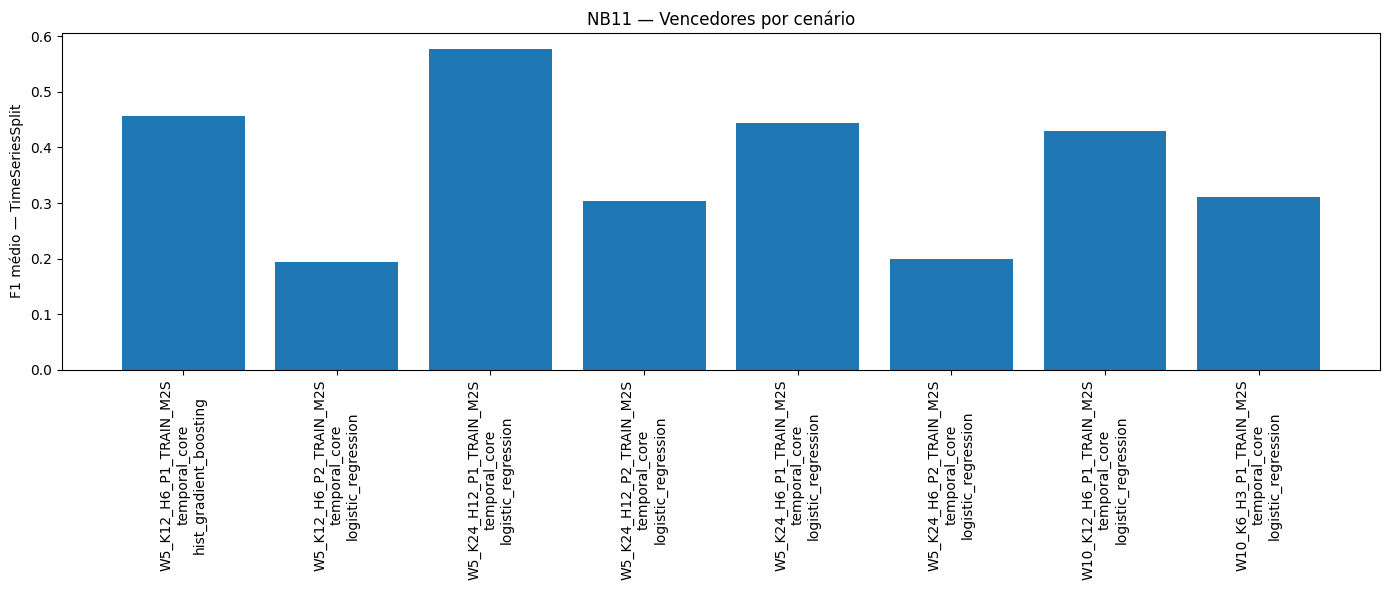

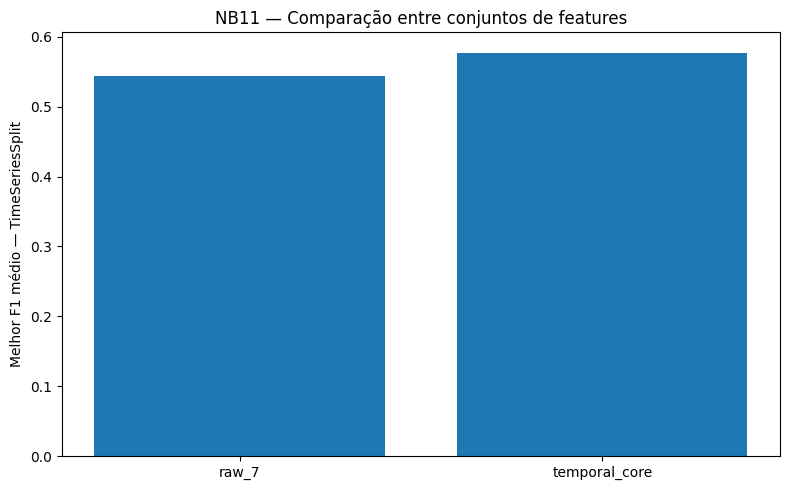

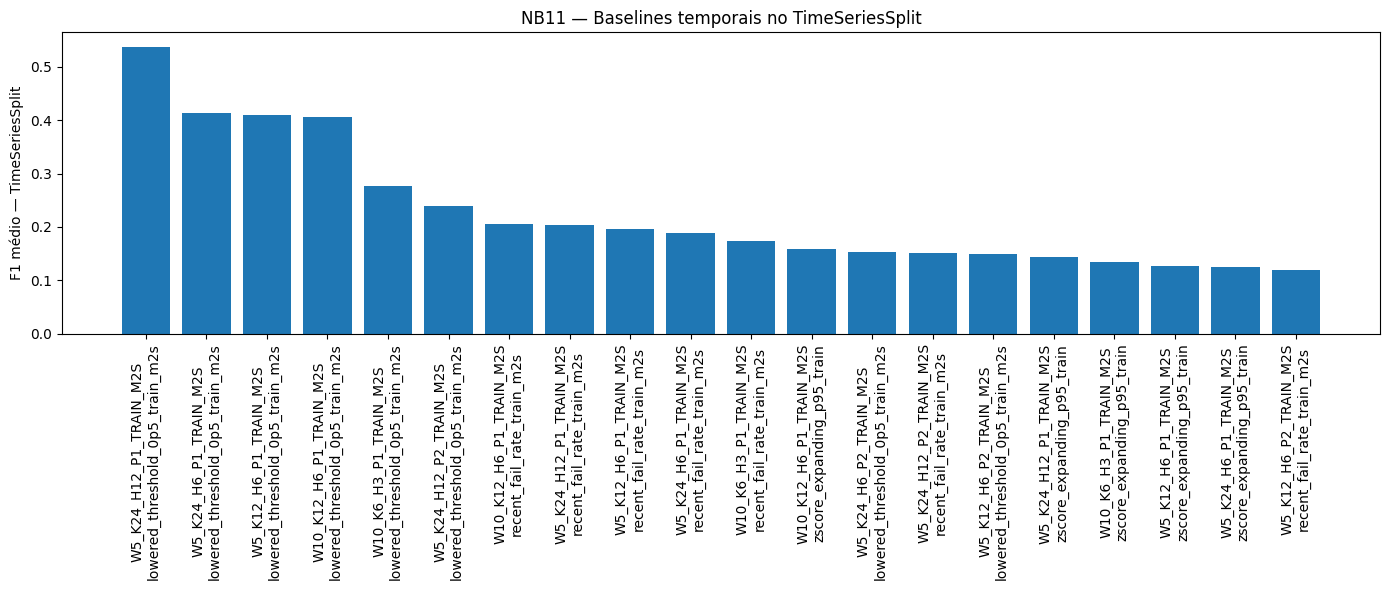

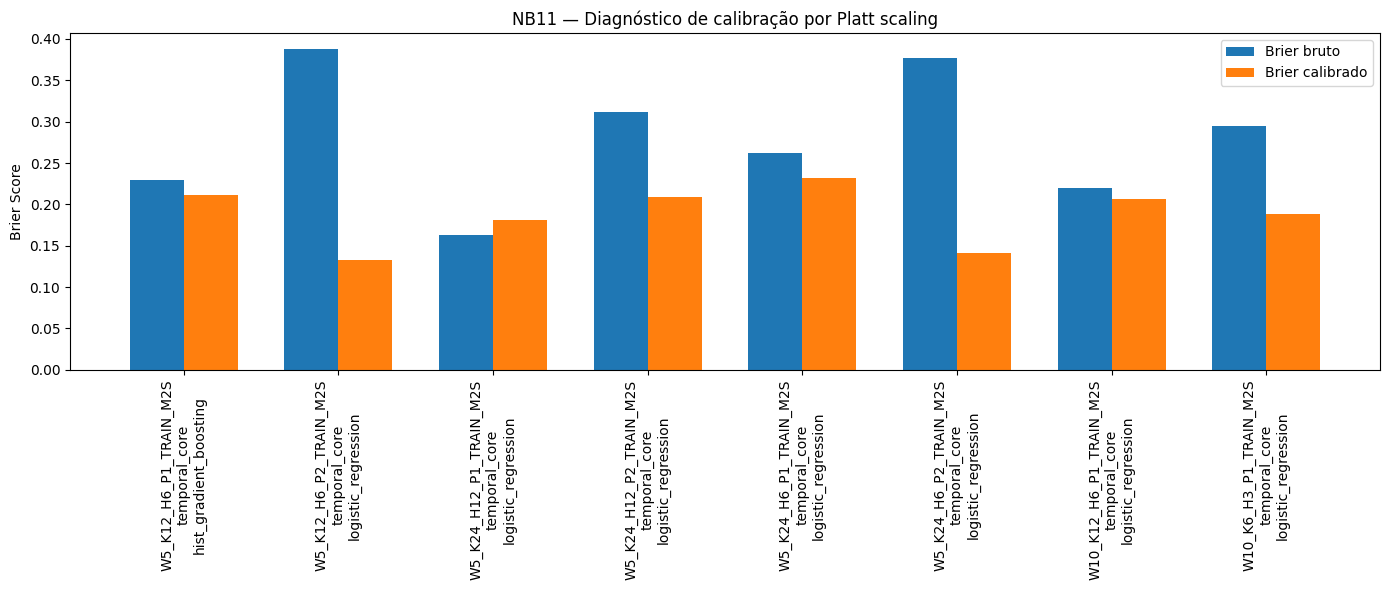

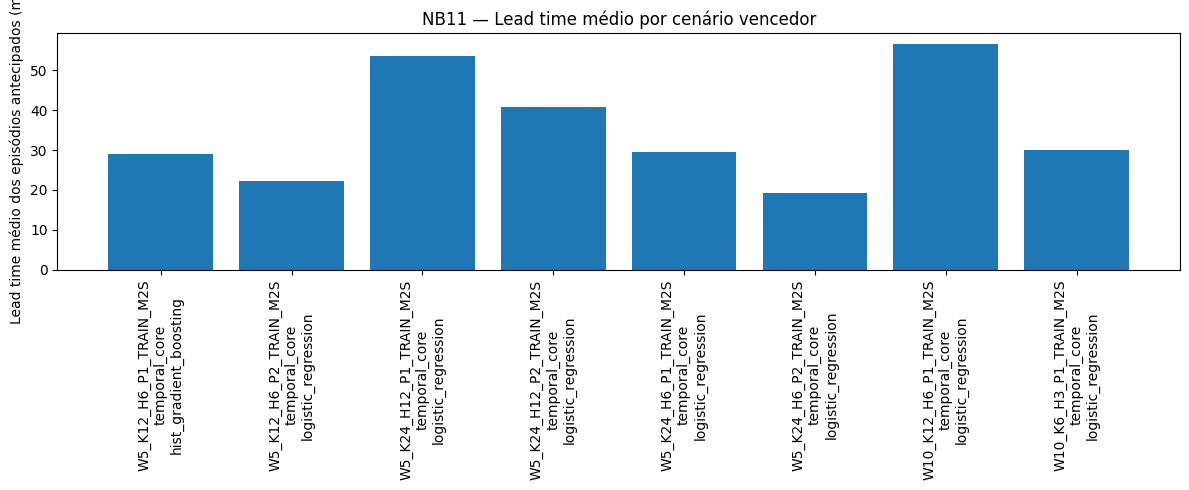


Resumo NB11:
{
  "notebook": "NB11",
  "title": "Baselines Temporais, Modelos Supervisionados e Lead Time Inicial",
  "executed_at": "2026-05-24 05:06:16",
  "n_scenarios_evaluated": 8,
  "validation_main": "TimeSeriesSplit",
  "validation_complementary": "fixed_80_20",
  "fixed_train_frac": 0.8,
  "n_splits_tscv": 5,
  "default_threshold": 0.5,
  "winner": {
    "scenario_label": "W5_K24_H12_P1_TRAIN_M2S",
    "feature_set": "temporal_core",
    "model": "logistic_regression",
    "f1_tscv_mean": 0.5773731424098736,
    "f1_tscv_std": 0.24078680558043347,
    "recall_tscv_mean": 0.8330878751100095,
    "recall_tscv_std": 0.09020568188238064,
    "precision_tscv_mean": 0.4818862788688552,
    "precision_tscv_std": 0.25651725425862437,
    "roc_auc_tscv_mean": 0.647357681048103,
    "average_precision_tscv_mean": 0.5594808237088985,
    "brier_tscv_mean": 0.25140332067954896,
    "n_features": 14,
    "features": [
      "fail_rate",
      "n_events",
      "n_failed",
      "n_machine

In [2]:
# ============================================================
# NB11 — Baselines Temporais, Modelos Supervisionados e Lead Time
# Pipeline PPCOMP/DM — Dissertação de Mestrado
#
# Versão revisada:
#   1. Baselines também no TimeSeriesSplit.
#   2. Comparação entre conjuntos de features.
#   3. Features temporais causais reconstruídas quando ausentes.
#   4. Lead time com episódios avaliáveis.
#   5. Registro de recomendação defensiva para NB13/LSTM.
# ============================================================


# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS_TSCV = 5
FIXED_TRAIN_FRAC = 0.80
DEFAULT_THRESHOLD = 0.50

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB11 iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ============================================================
# 1. Paths do projeto
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    BASE_DIR = Path("/content/drive/MyDrive/Mestrado")
else:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "02-datasets"
FEATURES_DIR = DATA_DIR / "03-features"
MODELS_DIR = BASE_DIR / "03-models"
REPORTS_DIR = BASE_DIR / "04-reports"
NB11_DIR = REPORTS_DIR
NB11_LEGACY_DIR = REPORTS_DIR / "nb11"
FIGURES_DIR = REPORTS_DIR / "figures_nb11"

for p in [FEATURES_DIR, MODELS_DIR, REPORTS_DIR, NB11_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Backup leve dos artefatos anteriores do NB11.
# Os artefatos canônicos novos serão gravados diretamente em 04-reports/.
# O subdiretório antigo 04-reports/nb11 é preservado em backup, se existir.
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")
BACKUP_DIR = REPORTS_DIR / "_backup_previous_artifacts" / RUN_TIMESTAMP_FILE / "nb11"
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

def backup_existing_nb11_artifacts():
    import shutil

    patterns = [
        "11_*.csv",
        "11_*.json",
        "11_*.parquet",
        "11_*.txt",
    ]

    copied = []

    for pattern in patterns:
        for path in REPORTS_DIR.glob(pattern):
            if path.is_file():
                target = BACKUP_DIR / path.name
                shutil.copy2(path, target)
                copied.append(str(path))

    if NB11_LEGACY_DIR.exists() and NB11_LEGACY_DIR.is_dir():
        target_dir = BACKUP_DIR / "legacy_nb11"
        if not target_dir.exists():
            shutil.copytree(NB11_LEGACY_DIR, target_dir)
            copied.append(str(NB11_LEGACY_DIR))

    if copied:
        print(f"[BACKUP NB11] Artefatos anteriores copiados para: {BACKUP_DIR}")
    else:
        print("[BACKUP NB11] Nenhum artefato anterior encontrado para backup.")

backup_existing_nb11_artifacts()


print("BASE_DIR    :", BASE_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("REPORTS_DIR :", REPORTS_DIR)
print("NB11_DIR    :", NB11_DIR)
print("FIGURES_DIR :", FIGURES_DIR)


# ============================================================
# 2. Arquivos de entrada do NB10
# ============================================================

ADVANCED_JSON = REPORTS_DIR / "10_scenario_advanced_to_nb11.json"
STATES_PARQUET = REPORTS_DIR / "10_scenario_series_states.parquet"
EPISODES_PARQUET = REPORTS_DIR / "10_scenario_episodes.parquet"
DECISIONS_CSV = REPORTS_DIR / "10_scenario_decisions.csv"

required_inputs = [
    ADVANCED_JSON,
    STATES_PARQUET,
    EPISODES_PARQUET,
    DECISIONS_CSV,
]

missing = [str(p) for p in required_inputs if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Arquivos esperados do NB10 não encontrados:\n" + "\n".join(missing)
    )

print("Entradas do NB10 localizadas com sucesso.")


# ============================================================
# 3. Funções gerais
# ============================================================

def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def safe_brier(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return np.nan
    return brier_score_loss(y_true, np.clip(y_score, 0, 1))


def compute_ece(y_true, y_score, n_bins=10):
    """
    Expected Calibration Error simples.
    Usado como diagnóstico da calibração.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    if len(y_true) == 0:
        return np.nan

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        left = bins[i]
        right = bins[i + 1]

        if i == n_bins - 1:
            mask = (y_score >= left) & (y_score <= right)
        else:
            mask = (y_score >= left) & (y_score < right)

        if mask.sum() == 0:
            continue

        acc_bin = y_true[mask].mean()
        conf_bin = y_score[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc_bin - conf_bin)

    return float(ece)


def binary_metrics(y_true, y_score, threshold=0.5):
    """
    Métricas binárias padronizadas para modelos e baselines.
    y_score pode ser probabilidade, escore ou saída binária.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    if len(y_true) == 0:
        return {
            "n": 0,
            "positive_rate": np.nan,
            "threshold": threshold,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "roc_auc": np.nan,
            "average_precision": np.nan,
            "brier": np.nan,
            "tn": 0,
            "fp": 0,
            "fn": 0,
            "tp": 0,
        }

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "n": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(safe_auc(y_true, y_score)) if not np.isnan(safe_auc(y_true, y_score)) else np.nan,
        "average_precision": float(safe_ap(y_true, y_score)) if not np.isnan(safe_ap(y_true, y_score)) else np.nan,
        "brier": float(safe_brier(y_true, y_score)) if not np.isnan(safe_brier(y_true, y_score)) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def false_alerts_per_day(y_true, y_score, window_minutes, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    false_alerts = int(((y_pred == 1) & (y_true == 0)).sum())
    total_days = (len(y_true) * window_minutes) / (60 * 24)

    return {
        "false_alerts": false_alerts,
        "false_alerts_per_day": float(false_alerts / total_days) if total_days > 0 else np.nan,
    }


def infer_scenario_column(df: pd.DataFrame):
    candidates = [
        "scenario_label",
        "scenario",
        "scenario_id",
        "config_label",
        "label",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    raise ValueError("Não foi possível identificar a coluna de cenário.")


def infer_episode_columns(df_episodes: pd.DataFrame):
    start_candidates = [
        "start_bucket_id",
        "episode_start_bucket_id",
        "start_bucket",
        "bucket_start",
        "start",
    ]

    end_candidates = [
        "end_bucket_id",
        "episode_end_bucket_id",
        "end_bucket",
        "bucket_end",
        "end",
    ]

    start_col = next((c for c in start_candidates if c in df_episodes.columns), None)
    end_col = next((c for c in end_candidates if c in df_episodes.columns), None)

    if start_col is None or end_col is None:
        raise ValueError(
            "Não foi possível identificar colunas de início/fim dos episódios."
        )

    return start_col, end_col


def scenario_to_dict_list(obj):
    """
    Normaliza o JSON do NB10 para lista de cenários.
    """
    if isinstance(obj, list):
        return obj

    if isinstance(obj, dict):
        for key in [
            "advanced_to_nb11",
            "scenarios",
            "advanced_scenarios",
            "items",
        ]:
            if key in obj and isinstance(obj[key], list):
                return obj[key]

        if all(isinstance(v, dict) for v in obj.values()):
            out = []
            for k, v in obj.items():
                vv = dict(v)
                vv.setdefault("scenario_label", k)
                out.append(vv)
            return out

    raise ValueError("Formato não reconhecido para 10_scenario_advanced_to_nb11.json")


def get_scenario_label(scen):
    for k in [
        "scenario_label",
        "scenario",
        "scenario_id",
        "config_label",
        "label",
    ]:
        if k in scen:
            return str(scen[k])

    raise ValueError(f"Cenário sem identificador reconhecido: {scen}")


def get_first_available(dct, keys, default=None):
    for k in keys:
        if k in dct and dct[k] is not None:
            return dct[k]
    return default


def parse_int_from_label(label, token, default=None):
    try:
        parts = str(label).split("_")
        for p in parts:
            if p.startswith(token):
                return int(p.replace(token, ""))
    except Exception:
        return default
    return default


# ============================================================
# 4. Carregamento dos artefatos do NB10
# ============================================================

advanced_raw = read_json(ADVANCED_JSON)
advanced_scenarios = scenario_to_dict_list(advanced_raw)

df_states_all = pd.read_parquet(STATES_PARQUET)
df_episodes_all = pd.read_parquet(EPISODES_PARQUET)
df_decisions = pd.read_csv(DECISIONS_CSV)

scenario_col_states = infer_scenario_column(df_states_all)
scenario_col_episodes = infer_scenario_column(df_episodes_all)

episode_start_col, episode_end_col = infer_episode_columns(df_episodes_all)

print("Cenários promovidos:", len(advanced_scenarios))
print("Coluna de cenário em states  :", scenario_col_states)
print("Coluna de cenário em episodes:", scenario_col_episodes)
print("Coluna início episódio        :", episode_start_col)
print("Coluna fim episódio           :", episode_end_col)
print("df_states_all:", df_states_all.shape)
print("df_episodes_all:", df_episodes_all.shape)


# ============================================================
# 5. Features temporais causais e conjuntos de features
# ============================================================

RAW_7_FEATURES = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
]

TEMPORAL_CORE_FEATURES = RAW_7_FEATURES + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

TEMPORAL_FULL_FEATURES = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "mean_priority",
    "mean_req_cpus",
    "mean_req_mem",
    "req_cpus_presence_rate",
    "req_mem_presence_rate",
    "event_FAIL_count",
    "event_SCHEDULE_count",
    "event_FINISH_count",
    "event_ENABLE_count",
    "event_LOST_count",
    "event_EVICT_count",
    "event_KILL_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

FORBIDDEN_FEATURE_PATTERNS = [
    "target",
    "label",
    "state",
    "during",
    "before",
    "after",
    "critical",
    "episode",
    "future",
    "horizon",
    "bucket_start_us",
    "bucket_id",
    "time",
    "timestamp",
]


def add_causal_temporal_features(df: pd.DataFrame, window_minutes: int):
    """
    Reconstrói features temporais causais a partir de fail_rate.

    Todas as operações usam apenas informação disponível até t
    ou anterior a t, preservando causalidade.
    """
    if "fail_rate" not in df.columns:
        raise ValueError("fail_rate é necessária para criar features temporais causais.")

    df = df.sort_values("bucket_id").copy()

    df["lag_1"] = df["fail_rate"].shift(1)
    df["lag_2"] = df["fail_rate"].shift(2)
    df["lag_3"] = df["fail_rate"].shift(3)

    rolling_window = max(int(round(60 / window_minutes)), 1)

    # Rolling com shift(1) para não usar o valor corrente na estatística histórica.
    df["rolling_mean_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=1)
        .mean()
    )

    df["rolling_std_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=2)
        .std(ddof=0)
    )

    previous = df["fail_rate"].shift(1)
    df["pct_change"] = (df["fail_rate"] - previous) / previous.replace(0, np.nan)

    expanding_mean = df["fail_rate"].shift(1).expanding(min_periods=2).mean()
    expanding_std = df["fail_rate"].shift(1).expanding(min_periods=2).std(ddof=0)

    df["zscore_expanding"] = (
        (df["fail_rate"] - expanding_mean) / expanding_std.replace(0, np.nan)
    )

    temporal_cols = [
        "lag_1",
        "lag_2",
        "lag_3",
        "rolling_mean_1h",
        "rolling_std_1h",
        "pct_change",
        "zscore_expanding",
    ]

    df[temporal_cols] = (
        df[temporal_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    return df


def validate_feature_list(cols):
    """
    Defesa adicional contra colunas com risco de vazamento.
    """
    bad = []

    for c in cols:
        lower = c.lower()

        if c == "fail_rate":
            continue

        if any(p in lower for p in FORBIDDEN_FEATURE_PATTERNS):
            bad.append(c)

    if bad:
        raise ValueError(f"Features com risco de vazamento detectadas: {bad}")


def build_feature_sets(df: pd.DataFrame):
    """
    Constrói conjuntos de features disponíveis, evitando duplicatas.
    """
    candidates = {
        "raw_7": [c for c in RAW_7_FEATURES if c in df.columns and pd.api.types.is_numeric_dtype(df[c])],
        "temporal_core": [c for c in TEMPORAL_CORE_FEATURES if c in df.columns and pd.api.types.is_numeric_dtype(df[c])],
        "temporal_full": [c for c in TEMPORAL_FULL_FEATURES if c in df.columns and pd.api.types.is_numeric_dtype(df[c])],
    }

    feature_sets = {}
    seen = set()

    for name, cols in candidates.items():
        if len(cols) == 0:
            continue

        validate_feature_list(cols)

        signature = tuple(cols)

        if signature in seen:
            continue

        seen.add(signature)
        feature_sets[name] = cols

    if not feature_sets:
        raise ValueError("Nenhum conjunto de features pôde ser construído.")

    return feature_sets


# ============================================================
# 6. Construção/validação do alvo supervisionado
# ============================================================

def ensure_target_column(df: pd.DataFrame, scenario: dict):
    """
    Garante coluna y_nb11 para antecipação.

    Prioriza alvos já produzidos pelo NB10.
    Se não houver, reconstrói a partir do estado DURING e do horizonte H.
    """
    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
    ]

    df = df.copy()

    for c in target_candidates:
        if c in df.columns:
            df["y_nb11"] = df[c].astype(int)

            if "state" in df.columns:
                df = df[df["state"].isin(["NORMAL", "BEFORE"])].copy()

            for hcol in ["has_complete_horizon", "complete_horizon"]:
                if hcol in df.columns:
                    df = df[df[hcol].astype(bool)].copy()

            return df

    if "state" not in df.columns:
        raise ValueError(
            "Nenhuma coluna alvo encontrada e coluna 'state' ausente para reconstrução."
        )

    label = get_scenario_label(scenario)

    h_windows = int(
        get_first_available(
            scenario,
            ["h_windows", "H", "h", "horizon_windows"],
            parse_int_from_label(label, "H", default=12),
        )
    )

    df = df.sort_values("bucket_id").reset_index(drop=True).copy()
    states = df["state"].astype(str).values
    during = (states == "DURING")

    y = np.zeros(len(df), dtype=int)

    for step in range(1, h_windows + 1):
        shifted = np.zeros(len(df), dtype=bool)
        shifted[:-step] = during[step:]
        y = np.logical_or(y, shifted)

    df["y_nb11"] = y.astype(int)

    # Remove janelas sem horizonte futuro completo.
    df["has_complete_horizon_nb11"] = False
    if len(df) > h_windows:
        df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb11"] = True

    df = df[
        df["state"].isin(["NORMAL", "BEFORE"])
        & df["has_complete_horizon_nb11"]
    ].copy()

    return df


# ============================================================
# 7. Baselines causais
# ============================================================

def get_train_m2s_threshold(scenario: dict, df_train: pd.DataFrame):
    """
    Recupera train_m2s do cenário.
    Se não existir no JSON, estima como média + 2 desvios no treino.
    """
    possible = [
        "train_m2s",
        "threshold_train_m2s",
        "limiar_train_m2s",
        "threshold",
        "critical_threshold",
    ]

    val = get_first_available(scenario, possible, None)

    if val is not None:
        try:
            return float(val)
        except Exception:
            pass

    if "fail_rate" not in df_train.columns:
        raise ValueError("fail_rate ausente para estimar train_m2s.")

    return float(df_train["fail_rate"].mean() + 2.0 * df_train["fail_rate"].std(ddof=0))


def baseline_majority_zero(df_train, df_eval, threshold_value=None):
    return np.zeros(len(df_eval), dtype=float), {}


def baseline_recent_fail_rate(df_train, df_eval, threshold_value):
    """
    Baseline temporal ingênuo causal:
    alerta se fail_rate da janela anterior ultrapassa train_m2s.

    Para a primeira janela de teste, usa a última janela do treino como passado.
    """
    if len(df_train) > 0:
        bridge = pd.concat([df_train.tail(1), df_eval], ignore_index=True)
        prev_fail_rate = bridge["fail_rate"].shift(1).iloc[1:].values
    else:
        prev_fail_rate = df_eval["fail_rate"].shift(1).fillna(0.0).values

    scores = (prev_fail_rate >= threshold_value).astype(float)

    return scores, {
        "baseline_threshold": float(threshold_value),
    }


def baseline_lowered_threshold(df_train, df_eval, threshold_value):
    """
    Baseline de limiar rebaixado:
    alerta se fail_rate_t >= 0,5 * train_m2s.
    """
    lowered = 0.5 * threshold_value
    scores = (df_eval["fail_rate"].values >= lowered).astype(float)

    return scores, {
        "baseline_threshold": float(lowered),
    }


def baseline_zscore_causal(df_train, df_eval, threshold_value=None):
    """
    Baseline z-score causal:
    limiar definido no treino como p95 do zscore_expanding.
    """
    if "zscore_expanding" not in df_train.columns or "zscore_expanding" not in df_eval.columns:
        return np.zeros(len(df_eval), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "zscore_expanding_unavailable",
        }

    z_train = (
        df_train["zscore_expanding"]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(z_train) == 0:
        return np.zeros(len(df_eval), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "zscore_train_empty",
        }

    z_thr = float(np.nanpercentile(z_train.values, 95))

    scores = (
        df_eval["zscore_expanding"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(-np.inf)
        .values >= z_thr
    ).astype(float)

    return scores, {
        "baseline_threshold": z_thr,
    }


BASELINES = {
    "majority_zero": baseline_majority_zero,
    "recent_fail_rate_train_m2s": baseline_recent_fail_rate,
    "lowered_threshold_0p5_train_m2s": baseline_lowered_threshold,
    "zscore_expanding_p95_train": baseline_zscore_causal,
}


def evaluate_baselines_fixed(df, scenario, window_minutes):
    """
    Avalia baselines no corte fixo 80/20.
    """
    n = len(df)
    split_idx = int(np.floor(n * FIXED_TRAIN_FRAC))

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    y_test = df_test["y_nb11"].astype(int).values

    train_m2s = get_train_m2s_threshold(scenario, df_train)

    records = []

    for baseline_name, baseline_func in BASELINES.items():
        scores, extra = baseline_func(df_train, df_test, train_m2s)

        metrics = binary_metrics(y_test, scores, DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(
            y_test,
            scores,
            window_minutes=window_minutes,
            threshold=DEFAULT_THRESHOLD,
        )

        records.append({
            "scenario_label": get_scenario_label(scenario),
            "baseline": baseline_name,
            "validation": "fixed_80_20",
            "fold": np.nan,
            "n_train": int(len(df_train)),
            "n_test": int(len(df_test)),
            "train_positive_rate": float(df_train["y_nb11"].mean()) if len(df_train) else np.nan,
            "test_positive_rate": float(df_test["y_nb11"].mean()) if len(df_test) else np.nan,
            "train_m2s": float(train_m2s),
            **extra,
            **metrics,
            **fa,
        })

    return pd.DataFrame(records)


def evaluate_baselines_tscv(df, scenario, window_minutes):
    """
    Avalia baselines no TimeSeriesSplit.
    """
    records = []

    y_all = df["y_nb11"].astype(int).values
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_TSCV)

    for fold_id, (tr_idx, te_idx) in enumerate(tscv.split(df), start=1):
        df_train = df.iloc[tr_idx].copy()
        df_test = df.iloc[te_idx].copy()

        y_train = df_train["y_nb11"].astype(int).values
        y_test = df_test["y_nb11"].astype(int).values

        if len(np.unique(y_test)) < 2:
            continue

        train_m2s = get_train_m2s_threshold(scenario, df_train)

        for baseline_name, baseline_func in BASELINES.items():
            scores, extra = baseline_func(df_train, df_test, train_m2s)

            metrics = binary_metrics(y_test, scores, DEFAULT_THRESHOLD)
            fa = false_alerts_per_day(
                y_test,
                scores,
                window_minutes=window_minutes,
                threshold=DEFAULT_THRESHOLD,
            )

            records.append({
                "scenario_label": get_scenario_label(scenario),
                "baseline": baseline_name,
                "validation": "timeseries_split",
                "fold": int(fold_id),
                "n_train": int(len(df_train)),
                "n_test": int(len(df_test)),
                "train_positive_rate": float(np.mean(y_train)),
                "test_positive_rate": float(np.mean(y_test)),
                "train_m2s": float(train_m2s),
                **extra,
                **metrics,
                **fa,
            })

    return pd.DataFrame(records)


# ============================================================
# 8. Modelos supervisionados
# ============================================================

def make_models():
    return {
        "logistic_regression": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    solver="lbfgs",
                )),
            ]
        ),

        "random_forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),

        "hist_gradient_boosting": HistGradientBoostingClassifier(
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
        ),
    }


def compute_sample_weight_balanced(y):
    y = np.asarray(y).astype(int)
    n = len(y)
    classes, counts = np.unique(y, return_counts=True)

    weights = np.ones(n, dtype=float)

    for cls, cnt in zip(classes, counts):
        weights[y == cls] = n / (len(classes) * cnt)

    return weights


def fit_model(model_name, estimator, X_train, y_train):
    est = clone(estimator)

    if model_name == "hist_gradient_boosting":
        sw = compute_sample_weight_balanced(y_train)
        est.fit(X_train, y_train, sample_weight=sw)
    else:
        est.fit(X_train, y_train)

    return est


def predict_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]

    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))

    return estimator.predict(X).astype(float)


def evaluate_models_for_feature_set(df, scenario, feature_set_name, feature_cols, window_minutes, h_windows):
    """
    Avalia modelos para um cenário e um conjunto de features.
    """
    df = df.copy()

    df[feature_cols] = (
        df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    X = df[feature_cols].values
    y = df["y_nb11"].astype(int).values

    models = make_models()
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_TSCV)

    tscv_records = []
    fixed_records = []
    raw_score_records = []

    # ------------------------------------------------------------
    # TimeSeriesSplit
    # ------------------------------------------------------------

    for model_name, estimator in models.items():
        for fold_id, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
            X_train, X_test = X[tr_idx], X[te_idx]
            y_train, y_test = y[tr_idx], y[te_idx]

            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                continue

            est = fit_model(model_name, estimator, X_train, y_train)
            score_test = predict_score(est, X_test)

            metrics = binary_metrics(y_test, score_test, DEFAULT_THRESHOLD)
            fa = false_alerts_per_day(
                y_test,
                score_test,
                window_minutes=window_minutes,
                threshold=DEFAULT_THRESHOLD,
            )

            tscv_records.append({
                "scenario_label": get_scenario_label(scenario),
                "feature_set": feature_set_name,
                "model": model_name,
                "validation": "timeseries_split",
                "fold": int(fold_id),
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "train_positive_rate": float(y_train.mean()),
                "test_positive_rate": float(y_test.mean()),
                "n_features": int(len(feature_cols)),
                "features": "|".join(feature_cols),
                **metrics,
                **fa,
            })

    # ------------------------------------------------------------
    # Corte fixo 80/20
    # ------------------------------------------------------------

    n = len(df)
    split_idx = int(np.floor(n * FIXED_TRAIN_FRAC))

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    X_train = df_train[feature_cols].values
    y_train = df_train["y_nb11"].astype(int).values

    X_test = df_test[feature_cols].values
    y_test = df_test["y_nb11"].astype(int).values

    for model_name, estimator in models.items():
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue

        est = fit_model(model_name, estimator, X_train, y_train)
        score_test = predict_score(est, X_test)

        metrics = binary_metrics(y_test, score_test, DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(
            y_test,
            score_test,
            window_minutes=window_minutes,
            threshold=DEFAULT_THRESHOLD,
        )

        fixed_records.append({
            "scenario_label": get_scenario_label(scenario),
            "feature_set": feature_set_name,
            "model": model_name,
            "validation": "fixed_80_20",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "train_positive_rate": float(y_train.mean()),
            "test_positive_rate": float(y_test.mean()),
            "n_features": int(len(feature_cols)),
            "features": "|".join(feature_cols),
            **metrics,
            **fa,
        })

        tmp = df_test[["bucket_id"]].copy()
        tmp["scenario_label"] = get_scenario_label(scenario)
        tmp["feature_set"] = feature_set_name
        tmp["model"] = model_name
        tmp["validation"] = "fixed_80_20"
        tmp["y_true"] = y_test
        tmp["score_raw"] = score_test
        tmp["window_minutes"] = int(window_minutes)
        tmp["h_windows"] = int(h_windows)
        tmp["n_features"] = int(len(feature_cols))
        tmp["features"] = "|".join(feature_cols)

        raw_score_records.append(tmp)

    df_tscv = pd.DataFrame(tscv_records)
    df_fixed = pd.DataFrame(fixed_records)
    df_raw_scores = pd.concat(raw_score_records, ignore_index=True) if raw_score_records else pd.DataFrame()

    return df_tscv, df_fixed, df_raw_scores


# ============================================================
# 9. Resumos
# ============================================================

def summarize_model_metrics(df_tscv):
    if df_tscv.empty:
        return pd.DataFrame()

    rows = []

    group_cols = [
        "scenario_label",
        "feature_set",
        "model",
    ]

    for keys, g in df_tscv.groupby(group_cols):
        scenario_label, feature_set, model = keys

        rows.append({
            "scenario_label": scenario_label,
            "feature_set": feature_set,
            "model": model,
            "n_folds_valid": int(g["fold"].nunique()),
            "n_features": int(g["n_features"].iloc[0]),
            "features": str(g["features"].iloc[0]),

            "accuracy_tscv_mean": float(g["accuracy"].mean()),
            "accuracy_tscv_std": float(g["accuracy"].std(ddof=0)),

            "precision_tscv_mean": float(g["precision"].mean()),
            "precision_tscv_std": float(g["precision"].std(ddof=0)),

            "recall_tscv_mean": float(g["recall"].mean()),
            "recall_tscv_std": float(g["recall"].std(ddof=0)),

            "f1_tscv_mean": float(g["f1"].mean()),
            "f1_tscv_std": float(g["f1"].std(ddof=0)),

            "roc_auc_tscv_mean": float(g["roc_auc"].mean()),
            "roc_auc_tscv_std": float(g["roc_auc"].std(ddof=0)),

            "average_precision_tscv_mean": float(g["average_precision"].mean()),
            "average_precision_tscv_std": float(g["average_precision"].std(ddof=0)),

            "brier_tscv_mean": float(g["brier"].mean()),
            "brier_tscv_std": float(g["brier"].std(ddof=0)),

            "false_alerts_per_day_tscv_mean": float(g["false_alerts_per_day"].mean()),
            "false_alerts_per_day_tscv_std": float(g["false_alerts_per_day"].std(ddof=0)),
        })

    return pd.DataFrame(rows)


def summarize_baselines(df_baselines):
    if df_baselines.empty:
        return pd.DataFrame()

    rows = []

    group_cols = [
        "scenario_label",
        "baseline",
        "validation",
    ]

    for keys, g in df_baselines.groupby(group_cols):
        scenario_label, baseline, validation = keys

        rows.append({
            "scenario_label": scenario_label,
            "baseline": baseline,
            "validation": validation,
            "n_folds_valid": int(g["fold"].dropna().nunique()) if validation == "timeseries_split" else np.nan,

            "accuracy_mean": float(g["accuracy"].mean()),
            "precision_mean": float(g["precision"].mean()),
            "recall_mean": float(g["recall"].mean()),
            "f1_mean": float(g["f1"].mean()),
            "roc_auc_mean": float(g["roc_auc"].mean()),
            "average_precision_mean": float(g["average_precision"].mean()),
            "brier_mean": float(g["brier"].mean()),
            "false_alerts_per_day_mean": float(g["false_alerts_per_day"].mean()),
        })

    return pd.DataFrame(rows)


def summarize_feature_sets(df_summary):
    if df_summary.empty:
        return pd.DataFrame()

    rows = []

    for feature_set, g in df_summary.groupby("feature_set"):
        best = g.sort_values(
            ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
            ascending=[False, False, False],
        ).iloc[0]

        rows.append({
            "feature_set": feature_set,
            "best_scenario_label": best["scenario_label"],
            "best_model": best["model"],
            "best_f1_tscv_mean": float(best["f1_tscv_mean"]),
            "best_f1_tscv_std": float(best["f1_tscv_std"]),
            "best_recall_tscv_mean": float(best["recall_tscv_mean"]),
            "best_precision_tscv_mean": float(best["precision_tscv_mean"]),
            "best_average_precision_tscv_mean": float(best["average_precision_tscv_mean"]),
            "best_n_features": int(best["n_features"]),
            "features": best["features"],
        })

    return pd.DataFrame(rows)


# ============================================================
# 10. Calibração
# ============================================================

def calibrate_winner_fixed_split(df, scenario, feature_set_name, feature_cols, model_name, window_minutes, h_windows):
    """
    Calibração diagnóstica por Platt scaling no vencedor do cenário.
    Usa apenas o trecho de treino para ajustar modelo e calibrador.
    Aplica no teste fixo.
    """
    df = df.copy()

    df[feature_cols] = (
        df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    n = len(df)
    split_idx = int(np.floor(n * FIXED_TRAIN_FRAC))

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    X_train = df_train[feature_cols].values
    y_train = df_train["y_nb11"].astype(int).values

    X_test = df_test[feature_cols].values
    y_test = df_test["y_nb11"].astype(int).values

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return pd.DataFrame(), pd.DataFrame()

    estimator = make_models()[model_name]
    base_est = fit_model(model_name, estimator, X_train, y_train)

    score_raw = predict_score(base_est, X_test)

    try:
        calibrator = CalibratedClassifierCV(
            estimator=base_est,
            method="sigmoid",
            cv="prefit",
        )
    except TypeError:
        calibrator = CalibratedClassifierCV(
            base_estimator=base_est,
            method="sigmoid",
            cv="prefit",
        )

    calibrator.fit(X_train, y_train)
    score_calibrated = calibrator.predict_proba(X_test)[:, 1]

    raw_brier = safe_brier(y_test, score_raw)
    cal_brier = safe_brier(y_test, score_calibrated)

    raw_ece = compute_ece(y_test, score_raw)
    cal_ece = compute_ece(y_test, score_calibrated)

    calibration_statement = (
        "calibrated_probability_candidate"
        if cal_brier < raw_brier and cal_ece < raw_ece
        else "relative_risk_score_preferred"
    )

    df_calibration = pd.DataFrame([{
        "scenario_label": get_scenario_label(scenario),
        "feature_set": feature_set_name,
        "model": model_name,
        "calibration_method": "platt_sigmoid_prefit_train_only",
        "brier_raw": float(raw_brier),
        "brier_calibrated": float(cal_brier),
        "ece_raw": float(raw_ece),
        "ece_calibrated": float(cal_ece),
        "roc_auc_raw": float(safe_auc(y_test, score_raw)) if not np.isnan(safe_auc(y_test, score_raw)) else np.nan,
        "roc_auc_calibrated": float(safe_auc(y_test, score_calibrated)) if not np.isnan(safe_auc(y_test, score_calibrated)) else np.nan,
        "average_precision_raw": float(safe_ap(y_test, score_raw)) if not np.isnan(safe_ap(y_test, score_raw)) else np.nan,
        "average_precision_calibrated": float(safe_ap(y_test, score_calibrated)) if not np.isnan(safe_ap(y_test, score_calibrated)) else np.nan,
        "brier_improved": bool(cal_brier < raw_brier),
        "ece_improved": bool(cal_ece < raw_ece),
        "calibration_statement": calibration_statement,
    }])

    df_scores = df_test[["bucket_id"]].copy()
    df_scores["scenario_label"] = get_scenario_label(scenario)
    df_scores["feature_set"] = feature_set_name
    df_scores["model"] = model_name
    df_scores["validation"] = "fixed_80_20"
    df_scores["y_true"] = y_test
    df_scores["score_raw"] = score_raw
    df_scores["score_calibrated"] = score_calibrated
    df_scores["window_minutes"] = int(window_minutes)
    df_scores["h_windows"] = int(h_windows)
    df_scores["n_features"] = int(len(feature_cols))
    df_scores["features"] = "|".join(feature_cols)

    return df_calibration, df_scores


# ============================================================
# 11. Lead time e antecipação por episódio
# ============================================================

def compute_episode_anticipation(
    df_scores: pd.DataFrame,
    df_episodes: pd.DataFrame,
    scenario_label: str,
    h_windows: int,
    window_minutes: int,
    score_col: str = "score_calibrated",
    threshold: float = 0.5,
):
    """
    Calcula lead time por episódio.

    Nesta versão, um episódio só entra no denominador se o intervalo
    [episode_start - H, episode_start - 1] possuir escores disponíveis.
    Isso evita misturar episódios fora do trecho efetivamente pontuado.
    """
    eps = df_episodes[
        df_episodes[scenario_col_episodes].astype(str) == str(scenario_label)
    ].copy()

    if eps.empty or df_scores.empty:
        return pd.DataFrame(), {
            "scenario_label": scenario_label,
            "n_total_episodes_in_scenario": int(len(eps)),
            "n_evaluable_episodes": 0,
            "n_anticipated": 0,
            "episode_anticipation_rate": np.nan,
            "lead_time_windows_mean": np.nan,
            "lead_time_minutes_mean": np.nan,
            "lead_time_windows_median": np.nan,
            "lead_time_minutes_median": np.nan,
        }

    score_buckets = set(df_scores["bucket_id"].astype(int).tolist())
    score_lookup = df_scores.set_index("bucket_id")[score_col].to_dict()

    rows = []

    for _, ep in eps.iterrows():
        ep_start = int(ep[episode_start_col])
        ep_end = int(ep[episode_end_col])

        previous_window = list(range(ep_start - h_windows, ep_start))

        # Episódio avaliável apenas se todas as H janelas anteriores têm score.
        is_evaluable = all(b in score_buckets for b in previous_window)

        if not is_evaluable:
            continue

        alert_buckets = [
            b for b in previous_window
            if score_lookup.get(b, -np.inf) >= threshold
        ]

        if len(alert_buckets) > 0:
            first_alert_bucket = int(min(alert_buckets))
            lead_windows = int(ep_start - first_alert_bucket)
            anticipated = 1
        else:
            first_alert_bucket = np.nan
            lead_windows = np.nan
            anticipated = 0

        rows.append({
            "scenario_label": scenario_label,
            "episode_start_bucket_id": ep_start,
            "episode_end_bucket_id": ep_end,
            "h_windows": int(h_windows),
            "window_minutes": int(window_minutes),
            "score_col": score_col,
            "threshold": float(threshold),
            "anticipated": int(anticipated),
            "first_alert_bucket_id": first_alert_bucket,
            "lead_time_windows": lead_windows,
            "lead_time_minutes": lead_windows * window_minutes if not pd.isna(lead_windows) else np.nan,
        })

    df_detail = pd.DataFrame(rows)

    if df_detail.empty:
        summary = {
            "scenario_label": scenario_label,
            "n_total_episodes_in_scenario": int(len(eps)),
            "n_evaluable_episodes": 0,
            "n_anticipated": 0,
            "episode_anticipation_rate": np.nan,
            "lead_time_windows_mean": np.nan,
            "lead_time_minutes_mean": np.nan,
            "lead_time_windows_median": np.nan,
            "lead_time_minutes_median": np.nan,
        }

        return df_detail, summary

    anticipated_df = df_detail[df_detail["anticipated"] == 1]

    summary = {
        "scenario_label": scenario_label,
        "n_total_episodes_in_scenario": int(len(eps)),
        "n_evaluable_episodes": int(len(df_detail)),
        "n_anticipated": int(df_detail["anticipated"].sum()),
        "episode_anticipation_rate": float(df_detail["anticipated"].mean()),
        "lead_time_windows_mean": float(anticipated_df["lead_time_windows"].mean()) if len(anticipated_df) else np.nan,
        "lead_time_minutes_mean": float(anticipated_df["lead_time_minutes"].mean()) if len(anticipated_df) else np.nan,
        "lead_time_windows_median": float(anticipated_df["lead_time_windows"].median()) if len(anticipated_df) else np.nan,
        "lead_time_minutes_median": float(anticipated_df["lead_time_minutes"].median()) if len(anticipated_df) else np.nan,
    }

    return df_detail, summary


# ============================================================
# 12. Avaliação completa de um cenário
# ============================================================


def prepare_scenario_full_feature_frame(scenario):
    """
    Constrói a série completa do cenário com features temporais causais.

    Este artefato é importante para notebooks posteriores, especialmente o NB13,
    porque preserva a continuidade temporal e materializa as mesmas features
    causais reconstruídas pelo NB11.
    """
    scenario_label = get_scenario_label(scenario)

    window_minutes = int(
        get_first_available(
            scenario,
            ["window_minutes", "w_minutes", "W", "granularity_minutes"],
            parse_int_from_label(scenario_label, "W", default=5),
        )
    )

    h_windows = int(
        get_first_available(
            scenario,
            ["h_windows", "H", "h", "horizon_windows"],
            parse_int_from_label(scenario_label, "H", default=12),
        )
    )

    df = df_states_all[
        df_states_all[scenario_col_states].astype(str) == str(scenario_label)
    ].copy()

    if df.empty:
        raise ValueError(f"Nenhuma linha encontrada em states para {scenario_label}.")

    if "bucket_id" not in df.columns:
        raise ValueError("Coluna bucket_id é obrigatória.")

    df = df.sort_values("bucket_id").reset_index(drop=True)

    # Materializa no dataframe completo as features temporais causais do NB11.
    df = add_causal_temporal_features(df, window_minutes)

    # Mantém o alvo original do NB10, quando disponível, sem usar como feature.
    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
    ]

    if "y_nb11" in df.columns:
        df = df.drop(columns=["y_nb11"])

    target_col = None
    for c in target_candidates:
        if c in df.columns:
            target_col = c
            df["y_nb11"] = df[c].astype(int)
            break

    if target_col is None and "state" in df.columns:
        states = df["state"].astype(str).values
        during = (states == "DURING")
        y = np.zeros(len(df), dtype=int)

        for step in range(1, h_windows + 1):
            shifted = np.zeros(len(df), dtype=bool)
            shifted[:-step] = during[step:]
            y = np.logical_or(y, shifted)

        df["y_nb11"] = y.astype(int)
        target_col = "reconstructed_from_state"

    if "eligible_supervised" not in df.columns:
        df["eligible_supervised"] = False

        if "state" in df.columns:
            valid_state = df["state"].isin(["NORMAL", "BEFORE"])
        else:
            valid_state = pd.Series(True, index=df.index)

        has_horizon = pd.Series(False, index=df.index)
        if len(df) > h_windows:
            has_horizon.iloc[: len(df) - h_windows] = True

        df.loc[valid_state & has_horizon, "eligible_supervised"] = True

    df["scenario_label"] = scenario_label
    df["window_minutes_nb11"] = int(window_minutes)
    df["h_windows_nb11"] = int(h_windows)
    df["target_source_nb11"] = str(target_col)

    return df, window_minutes, h_windows


def prepare_scenario_dataframe(scenario):
    scenario_label = get_scenario_label(scenario)

    df_full, window_minutes, h_windows = prepare_scenario_full_feature_frame(scenario)

    # Garante alvo e restringe à tarefa supervisionada efetivamente usada no NB11.
    df = ensure_target_column(df_full, scenario)

    df = df.sort_values("bucket_id").reset_index(drop=True)

    feature_sets = build_feature_sets(df)

    return df, feature_sets, window_minutes, h_windows, df_full


def evaluate_scenario(scenario):
    scenario_label = get_scenario_label(scenario)

    print("\n" + "=" * 90)
    print("Cenário:", scenario_label)
    print("=" * 90)

    df, feature_sets, window_minutes, h_windows, df_full = prepare_scenario_dataframe(scenario)

    y = df["y_nb11"].astype(int).values

    print("Linhas supervisionadas:", len(df))
    print("Taxa positiva:", round(float(y.mean()), 4))
    print("window_minutes:", window_minutes)
    print("h_windows:", h_windows)
    print("Feature sets disponíveis:")
    for name, cols in feature_sets.items():
        print("  -", name, len(cols), "features")

    # Baselines.
    df_baselines_fixed = evaluate_baselines_fixed(df, scenario, window_minutes)
    df_baselines_tscv = evaluate_baselines_tscv(df, scenario, window_minutes)
    df_baselines = pd.concat([df_baselines_fixed, df_baselines_tscv], ignore_index=True)

    # Modelos por conjunto de features.
    tscv_parts = []
    fixed_parts = []
    raw_score_parts = []

    for feature_set_name, feature_cols in feature_sets.items():
        print("Avaliando feature_set:", feature_set_name)

        df_tscv, df_fixed, df_raw_scores = evaluate_models_for_feature_set(
            df=df,
            scenario=scenario,
            feature_set_name=feature_set_name,
            feature_cols=feature_cols,
            window_minutes=window_minutes,
            h_windows=h_windows,
        )

        tscv_parts.append(df_tscv)
        fixed_parts.append(df_fixed)
        raw_score_parts.append(df_raw_scores)

    df_tscv = pd.concat(tscv_parts, ignore_index=True) if tscv_parts else pd.DataFrame()
    df_fixed = pd.concat(fixed_parts, ignore_index=True) if fixed_parts else pd.DataFrame()
    df_raw_scores = pd.concat(raw_score_parts, ignore_index=True) if raw_score_parts else pd.DataFrame()

    df_summary = summarize_model_metrics(df_tscv)

    if df_summary.empty:
        raise ValueError(f"Resumo vazio para {scenario_label}.")

    df_summary = df_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    df_summary["is_winner_tscv"] = False
    df_summary.loc[0, "is_winner_tscv"] = True

    winner = df_summary.iloc[0].to_dict()

    print("Vencedor do cenário:")
    print("  feature_set:", winner["feature_set"])
    print("  model      :", winner["model"])
    print("  F1 TSCV    :", round(float(winner["f1_tscv_mean"]), 4))

    # Calibração do vencedor do cenário.
    winner_feature_set = winner["feature_set"]
    winner_model = winner["model"]
    winner_features = feature_sets[winner_feature_set]

    df_calibration, df_scores_calibrated = calibrate_winner_fixed_split(
        df=df,
        scenario=scenario,
        feature_set_name=winner_feature_set,
        feature_cols=winner_features,
        model_name=winner_model,
        window_minutes=window_minutes,
        h_windows=h_windows,
    )

    # Lead time do vencedor do cenário.
    df_lead_detail = pd.DataFrame()
    df_lead_summary = pd.DataFrame()

    if not df_scores_calibrated.empty:
        df_lead_detail, lead_summary = compute_episode_anticipation(
            df_scores=df_scores_calibrated,
            df_episodes=df_episodes_all,
            scenario_label=scenario_label,
            h_windows=h_windows,
            window_minutes=window_minutes,
            score_col="score_calibrated",
            threshold=DEFAULT_THRESHOLD,
        )

        lead_summary["feature_set"] = winner_feature_set
        lead_summary["model"] = winner_model
        lead_summary["validation"] = "fixed_80_20"
        lead_summary["score_col"] = "score_calibrated"
        lead_summary["threshold"] = DEFAULT_THRESHOLD

        df_lead_summary = pd.DataFrame([lead_summary])

    return {
        "scenario_label": scenario_label,
        "df_prepared": df,
        "df_sequence_input": df_full,
        "feature_sets": feature_sets,
        "df_baselines": df_baselines,
        "df_tscv": df_tscv,
        "df_fixed": df_fixed,
        "df_raw_scores": df_raw_scores,
        "df_summary": df_summary,
        "df_calibration": df_calibration,
        "df_scores_calibrated": df_scores_calibrated,
        "df_lead_detail": df_lead_detail,
        "df_lead_summary": df_lead_summary,
    }


# ============================================================
# 13. Execução dos 8 cenários promovidos
# ============================================================

all_baselines = []
all_tscv = []
all_fixed = []
all_raw_scores = []
all_summary = []
all_calibration = []
all_scores_calibrated = []
all_lead_detail = []
all_lead_summary = []
all_model_input = []
all_sequence_input = []

scenario_prepared_info = []

for scen in advanced_scenarios:
    result = evaluate_scenario(scen)

    all_baselines.append(result["df_baselines"])
    all_tscv.append(result["df_tscv"])
    all_fixed.append(result["df_fixed"])
    all_raw_scores.append(result["df_raw_scores"])
    all_summary.append(result["df_summary"])
    all_calibration.append(result["df_calibration"])
    all_scores_calibrated.append(result["df_scores_calibrated"])
    all_lead_detail.append(result["df_lead_detail"])
    all_lead_summary.append(result["df_lead_summary"])

    model_input_df = result["df_prepared"].copy()
    model_input_df["scenario_label"] = result["scenario_label"]
    all_model_input.append(model_input_df)

    sequence_input_df = result["df_sequence_input"].copy()
    sequence_input_df["scenario_label"] = result["scenario_label"]
    all_sequence_input.append(sequence_input_df)

    scenario_prepared_info.append({
        "scenario_label": result["scenario_label"],
        "n_rows_supervised": int(len(result["df_prepared"])),
        "positive_rate": float(result["df_prepared"]["y_nb11"].mean()),
        "feature_sets": {
            name: {
                "n_features": len(cols),
                "features": cols,
            }
            for name, cols in result["feature_sets"].items()
        },
    })

df_baselines_all = pd.concat(all_baselines, ignore_index=True) if all_baselines else pd.DataFrame()
df_tscv_all = pd.concat(all_tscv, ignore_index=True) if all_tscv else pd.DataFrame()
df_fixed_all = pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame()
df_raw_scores_all = pd.concat(all_raw_scores, ignore_index=True) if all_raw_scores else pd.DataFrame()
df_summary_all = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()
df_calibration_all = pd.concat(all_calibration, ignore_index=True) if all_calibration else pd.DataFrame()
df_scores_calibrated_all = pd.concat(all_scores_calibrated, ignore_index=True) if all_scores_calibrated else pd.DataFrame()
df_lead_detail_all = pd.concat(all_lead_detail, ignore_index=True) if all_lead_detail else pd.DataFrame()
df_lead_summary_all = pd.concat(all_lead_summary, ignore_index=True) if all_lead_summary else pd.DataFrame()
df_model_input_all = pd.concat(all_model_input, ignore_index=True) if all_model_input else pd.DataFrame()
df_sequence_input_all = pd.concat(all_sequence_input, ignore_index=True) if all_sequence_input else pd.DataFrame()

df_baselines_summary = summarize_baselines(df_baselines_all)
df_feature_set_summary = summarize_feature_sets(df_summary_all)

print("\nExecução completa concluída.")
print("df_baselines_all       :", df_baselines_all.shape)
print("df_tscv_all            :", df_tscv_all.shape)
print("df_fixed_all           :", df_fixed_all.shape)
print("df_summary_all         :", df_summary_all.shape)
print("df_calibration_all     :", df_calibration_all.shape)
print("df_lead_summary_all    :", df_lead_summary_all.shape)
print("df_model_input_all     :", df_model_input_all.shape)
print("df_sequence_input_all  :", df_sequence_input_all.shape)


# ============================================================
# 14. Seleção do vencedor global do NB11
# ============================================================

if df_summary_all.empty:
    raise ValueError("Resumo geral vazio. Não foi possível selecionar vencedor global.")

df_scenario_winners = df_summary_all[
    df_summary_all["is_winner_tscv"] == True
].copy()

best_row = df_scenario_winners.sort_values(
    ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
    ascending=[False, False, False],
).iloc[0]

global_winner = {
    "scenario_label": best_row["scenario_label"],
    "feature_set": best_row["feature_set"],
    "model": best_row["model"],

    "f1_tscv_mean": float(best_row["f1_tscv_mean"]),
    "f1_tscv_std": float(best_row["f1_tscv_std"]),
    "recall_tscv_mean": float(best_row["recall_tscv_mean"]),
    "recall_tscv_std": float(best_row["recall_tscv_std"]),
    "precision_tscv_mean": float(best_row["precision_tscv_mean"]),
    "precision_tscv_std": float(best_row["precision_tscv_std"]),
    "roc_auc_tscv_mean": float(best_row["roc_auc_tscv_mean"]),
    "average_precision_tscv_mean": float(best_row["average_precision_tscv_mean"]),
    "brier_tscv_mean": float(best_row["brier_tscv_mean"]),

    "n_features": int(best_row["n_features"]),
    "features": str(best_row["features"]).split("|"),
}

nb13_quantitative_trigger = (
    global_winner["f1_tscv_mean"] < 0.45
    or global_winner["f1_tscv_std"] > 0.29
)

global_winner["nb13_quantitative_trigger"] = bool(nb13_quantitative_trigger)
global_winner["nb13_quantitative_trigger_rule"] = (
    "Executar NB13 se F1 médio TSCV < 0,45 ou desvio-padrão do F1 TSCV > 0,29."
)

# Novo direcionamento metodológico:
global_winner["nb13_defensive_recommended"] = True
global_winner["nb13_defensive_recommendation_reason"] = (
    "Executar LSTM no NB13 como experimento complementar defensivo, "
    "mesmo se o gatilho quantitativo não for ativado, em razão da relevância "
    "histórica e metodológica de LSTM em problemas temporais."
)

print("\nVencedor global NB11:")
print(json.dumps(global_winner, ensure_ascii=False, indent=2))


# ============================================================
# 15. Comparação com baselines no TSCV
# ============================================================

baseline_tscv_summary = df_baselines_summary[
    df_baselines_summary["validation"] == "timeseries_split"
].copy()

best_baseline_tscv = None

if not baseline_tscv_summary.empty:
    best_baseline_row = baseline_tscv_summary.sort_values(
        ["f1_mean", "recall_mean", "average_precision_mean"],
        ascending=[False, False, False],
    ).iloc[0]

    best_baseline_tscv = {
        "scenario_label": best_baseline_row["scenario_label"],
        "baseline": best_baseline_row["baseline"],
        "f1_mean": float(best_baseline_row["f1_mean"]),
        "recall_mean": float(best_baseline_row["recall_mean"]),
        "precision_mean": float(best_baseline_row["precision_mean"]),
        "roc_auc_mean": float(best_baseline_row["roc_auc_mean"]) if not pd.isna(best_baseline_row["roc_auc_mean"]) else np.nan,
        "average_precision_mean": float(best_baseline_row["average_precision_mean"]) if not pd.isna(best_baseline_row["average_precision_mean"]) else np.nan,
    }

print("\nMelhor baseline no TSCV:")
print(json.dumps(best_baseline_tscv, ensure_ascii=False, indent=2))


# ============================================================
# 16. Salvamento dos artefatos
# ============================================================


# Artefatos de entrada materializados para reuso por notebooks posteriores.
# 11_model_input_features.parquet contém a matriz supervisionada efetivamente usada pelo NB11.
# 11_sequence_input_features.parquet contém a série completa com features temporais causais,
# preservando continuidade temporal para modelos sequenciais como a LSTM do NB13.
if not df_model_input_all.empty:
    df_model_input_all.to_parquet(NB11_DIR / "11_model_input_features.parquet", index=False)

if not df_sequence_input_all.empty:
    df_sequence_input_all.to_parquet(NB11_DIR / "11_sequence_input_features.parquet", index=False)

nb11_feature_sets = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "raw_7": RAW_7_FEATURES,
    "temporal_core": TEMPORAL_CORE_FEATURES,
    "temporal_full": TEMPORAL_FULL_FEATURES,
    "forbidden_feature_patterns": FORBIDDEN_FEATURE_PATTERNS,
    "feature_sets_by_scenario": {
        item["scenario_label"]: item["feature_sets"]
        for item in scenario_prepared_info
    },
    "notes": [
        "raw_7, temporal_core e temporal_full são whitelists de features causais.",
        "A variável alvo, estados, flags de criticidade, campos de horizonte, identificadores e tempo absoluto não devem ser usados como features.",
        "11_model_input_features.parquet é a matriz supervisionada usada pelo NB11.",
        "11_sequence_input_features.parquet preserva a continuidade temporal para o NB13."
    ],
}

save_json(nb11_feature_sets, NB11_DIR / "11_feature_sets.json")

nb11_model_input_schema = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_input_path": str(NB11_DIR / "11_model_input_features.parquet"),
    "sequence_input_path": str(NB11_DIR / "11_sequence_input_features.parquet"),
    "target_column": "y_nb11",
    "endpoint_eligibility_column": "eligible_supervised",
    "scenario_column": "scenario_label",
    "time_order_column": "bucket_id",
    "allowed_feature_sets_file": str(NB11_DIR / "11_feature_sets.json"),
    "leakage_statement": (
        "Os artefatos de entrada materializam as features causais usadas ou disponíveis para modelagem. "
        "Campos de alvo, estado, criticidade, horizonte, elegibilidade, identificadores e tempo absoluto "
        "devem ser usados apenas para controle, filtro ou ordenação, nunca como features."
    ),
    "model_input_shape": list(df_model_input_all.shape),
    "sequence_input_shape": list(df_sequence_input_all.shape),
}

save_json(nb11_model_input_schema, NB11_DIR / "11_model_input_features_schema.json")

df_tscv_all.to_csv(NB11_DIR / "11_metrics_tscv.csv", index=False)
df_fixed_all.to_csv(NB11_DIR / "11_metrics_fixed_split.csv", index=False)
df_summary_all.to_csv(NB11_DIR / "11_metrics_summary.csv", index=False)

df_baselines_all.to_csv(NB11_DIR / "11_baselines_all.csv", index=False)
df_baselines_summary.to_csv(NB11_DIR / "11_baselines_summary.csv", index=False)

df_feature_set_summary.to_csv(NB11_DIR / "11_feature_set_summary.csv", index=False)

df_calibration_all.to_csv(NB11_DIR / "11_calibration_summary.csv", index=False)
df_lead_summary_all.to_csv(NB11_DIR / "11_lead_time_summary.csv", index=False)
df_lead_detail_all.to_csv(NB11_DIR / "11_episode_anticipation.csv", index=False)

if not df_raw_scores_all.empty:
    df_raw_scores_all.to_parquet(NB11_DIR / "11_scores_raw.parquet", index=False)

if not df_scores_calibrated_all.empty:
    df_scores_calibrated_all.to_parquet(NB11_DIR / "11_scores_calibrated.parquet", index=False)

save_json(global_winner, NB11_DIR / "11_winner_model.json")


# ============================================================
# 17. Figuras diagnósticas
# ============================================================

# Figura 1 — F1 médio TSCV por vencedor de cenário.
if not df_scenario_winners.empty:
    fig_df = df_scenario_winners.copy()
    fig_df["label"] = (
        fig_df["scenario_label"]
        + "\n"
        + fig_df["feature_set"]
        + "\n"
        + fig_df["model"]
    )

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["f1_tscv_mean"])
    plt.xticks(range(len(fig_df)), fig_df["label"], rotation=90)
    plt.ylabel("F1 médio — TimeSeriesSplit")
    plt.title("NB11 — Vencedores por cenário")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig01_f1_tscv_winners_by_scenario.png", dpi=200)
    plt.show()

# Figura 2 — Comparação de feature sets.
if not df_feature_set_summary.empty:
    fig_df = df_feature_set_summary.copy()

    plt.figure(figsize=(8, 5))
    plt.bar(fig_df["feature_set"], fig_df["best_f1_tscv_mean"])
    plt.ylabel("Melhor F1 médio — TimeSeriesSplit")
    plt.title("NB11 — Comparação entre conjuntos de features")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig02_feature_sets_f1.png", dpi=200)
    plt.show()

# Figura 3 — Baselines TSCV.
if not baseline_tscv_summary.empty:
    fig_df = baseline_tscv_summary.copy()
    fig_df["label"] = fig_df["scenario_label"] + "\n" + fig_df["baseline"]

    top = fig_df.sort_values("f1_mean", ascending=False).head(20)

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(top)), top["f1_mean"])
    plt.xticks(range(len(top)), top["label"], rotation=90)
    plt.ylabel("F1 médio — TimeSeriesSplit")
    plt.title("NB11 — Baselines temporais no TimeSeriesSplit")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig03_baselines_tscv_f1.png", dpi=200)
    plt.show()

# Figura 4 — Calibração Brier bruto vs calibrado.
if not df_calibration_all.empty:
    cal = df_calibration_all.copy()
    cal["label"] = (
        cal["scenario_label"]
        + "\n"
        + cal["feature_set"]
        + "\n"
        + cal["model"]
    )

    x = np.arange(len(cal))
    width = 0.35

    plt.figure(figsize=(14, 6))
    plt.bar(x - width / 2, cal["brier_raw"], width, label="Brier bruto")
    plt.bar(x + width / 2, cal["brier_calibrated"], width, label="Brier calibrado")
    plt.xticks(x, cal["label"], rotation=90)
    plt.ylabel("Brier Score")
    plt.title("NB11 — Diagnóstico de calibração por Platt scaling")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig04_brier_raw_vs_calibrated.png", dpi=200)
    plt.show()

# Figura 5 — Lead time médio.
if not df_lead_summary_all.empty:
    lead = df_lead_summary_all.copy()
    lead["label"] = (
        lead["scenario_label"]
        + "\n"
        + lead["feature_set"]
        + "\n"
        + lead["model"]
    )

    plt.figure(figsize=(12, 5))
    plt.bar(lead["label"], lead["lead_time_minutes_mean"])
    plt.xticks(rotation=90)
    plt.ylabel("Lead time médio dos episódios antecipados (min)")
    plt.title("NB11 — Lead time médio por cenário vencedor")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig05_lead_time_mean.png", dpi=200)
    plt.show()


# ============================================================
# 18. Sumário final do NB11
# ============================================================

calibration_statement = "not_available"

if not df_calibration_all.empty:
    gw_cal = df_calibration_all[
        (df_calibration_all["scenario_label"] == global_winner["scenario_label"])
        & (df_calibration_all["feature_set"] == global_winner["feature_set"])
        & (df_calibration_all["model"] == global_winner["model"])
    ]

    if not gw_cal.empty:
        calibration_statement = str(gw_cal.iloc[0]["calibration_statement"])

lead_time_statement = {}

if not df_lead_summary_all.empty:
    gw_lead = df_lead_summary_all[
        (df_lead_summary_all["scenario_label"] == global_winner["scenario_label"])
        & (df_lead_summary_all["feature_set"] == global_winner["feature_set"])
        & (df_lead_summary_all["model"] == global_winner["model"])
    ]

    if not gw_lead.empty:
        r = gw_lead.iloc[0]

        lead_time_statement = {
            "n_total_episodes_in_scenario": int(r["n_total_episodes_in_scenario"]),
            "n_evaluable_episodes": int(r["n_evaluable_episodes"]),
            "n_anticipated": int(r["n_anticipated"]),
            "episode_anticipation_rate": float(r["episode_anticipation_rate"]) if not pd.isna(r["episode_anticipation_rate"]) else np.nan,
            "lead_time_minutes_mean": float(r["lead_time_minutes_mean"]) if not pd.isna(r["lead_time_minutes_mean"]) else np.nan,
            "lead_time_minutes_median": float(r["lead_time_minutes_median"]) if not pd.isna(r["lead_time_minutes_median"]) else np.nan,
        }

nb11_summary = {
    "notebook": "NB11",
    "title": "Baselines Temporais, Modelos Supervisionados e Lead Time Inicial",
    "executed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "n_scenarios_evaluated": int(len(advanced_scenarios)),
    "validation_main": "TimeSeriesSplit",
    "validation_complementary": "fixed_80_20",
    "fixed_train_frac": FIXED_TRAIN_FRAC,
    "n_splits_tscv": N_SPLITS_TSCV,
    "default_threshold": DEFAULT_THRESHOLD,

    "winner": global_winner,
    "best_baseline_tscv": best_baseline_tscv,
    "calibration_statement": calibration_statement,
    "lead_time_statement": lead_time_statement,

    "scenario_prepared_info": scenario_prepared_info,

    "methodological_notes": [
        "Baselines temporais foram avaliados no TimeSeriesSplit e no corte fixo 80/20.",
        "O baseline temporal ingênuo não usa estado BEFORE como sinal operacional.",
        "Features temporais causais foram reconstruídas no NB11 quando ausentes.",
        "Foram comparados os conjuntos raw_7, temporal_core e temporal_full, conforme disponibilidade das colunas.",
        "A seleção de features permanece controlada por whitelist, reduzindo risco de vazamento.",
        "O corte fixo 80/20 é complementar; a evidência principal é TimeSeriesSplit.",
        "A calibração por Platt scaling é diagnóstica; se não melhorar Brier/ECE, os escores devem ser tratados como risco relativo.",
        "O lead time usa apenas episódios avaliáveis, isto é, episódios cujo intervalo anterior de H janelas possui escores disponíveis.",
        "O NB13/LSTM permanece complementar, mas passa a ser recomendado defensivamente por relevância metodológica em problemas temporais.",
        "A matriz supervisionada usada pelo NB11 foi materializada em 11_model_input_features.parquet.",
        "A matriz temporal contínua para o NB13 foi materializada em 11_sequence_input_features.parquet.",
        "Os conjuntos raw_7, temporal_core e temporal_full foram persistidos em 11_feature_sets.json para reuso controlado pelo NB13.",
    ],

    "outputs": {
        "metrics_tscv": str(NB11_DIR / "11_metrics_tscv.csv"),
        "metrics_fixed_split": str(NB11_DIR / "11_metrics_fixed_split.csv"),
        "metrics_summary": str(NB11_DIR / "11_metrics_summary.csv"),
        "baselines_all": str(NB11_DIR / "11_baselines_all.csv"),
        "baselines_summary": str(NB11_DIR / "11_baselines_summary.csv"),
        "feature_set_summary": str(NB11_DIR / "11_feature_set_summary.csv"),
        "calibration_summary": str(NB11_DIR / "11_calibration_summary.csv"),
        "lead_time_summary": str(NB11_DIR / "11_lead_time_summary.csv"),
        "episode_anticipation": str(NB11_DIR / "11_episode_anticipation.csv"),
        "scores_raw": str(NB11_DIR / "11_scores_raw.parquet"),
        "scores_calibrated": str(NB11_DIR / "11_scores_calibrated.parquet"),
        "winner_model": str(NB11_DIR / "11_winner_model.json"),
        "model_input_features": str(NB11_DIR / "11_model_input_features.parquet"),
        "sequence_input_features": str(NB11_DIR / "11_sequence_input_features.parquet"),
        "feature_sets": str(NB11_DIR / "11_feature_sets.json"),
        "model_input_features_schema": str(NB11_DIR / "11_model_input_features_schema.json"),
    },
}

save_json(nb11_summary, NB11_DIR / "11_nb11_summary.json")

print("\nResumo NB11:")
print(json.dumps(nb11_summary, ensure_ascii=False, indent=2))

print("\nArtefatos salvos em:", NB11_DIR)
print("Figuras salvas em:", FIGURES_DIR)
print("NB11 finalizado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

## 16. Achados Experimentais da Execução

### 16.1 Síntese da execução

O NB11 foi executado com sucesso como etapa de avaliação de baselines temporais, modelos supervisionados tabulares, conjuntos de features, calibração inicial e lead time bruto.

A execução utilizou os 8 cenários promovidos pelo NB10 para modelagem supervisionada. Esses cenários foram derivados da etapa anterior, que havia selecionado configurações metodologicamente defensáveis a partir de limiares causais, granularidades temporais, persistência mínima e configurações K/H.

Nesta versão revisada, o NB11 incorporou três ajustes importantes em relação à primeira execução:

1. os baselines temporais passaram a ser avaliados também no `TimeSeriesSplit`, e não apenas no corte fixo 80/20;
2. foram comparados conjuntos de features, distinguindo variáveis brutas (`raw_7`) e variáveis temporais causais (`temporal_core`);
3. a matriz supervisionada usada no NB11 e a matriz temporal contínua destinada ao NB13 passaram a ser materializadas em artefatos próprios, permitindo rastreabilidade e reuso controlado dos mesmos conjuntos de features.

A validação principal foi realizada por `TimeSeriesSplit` com 5 partições temporais progressivas. O corte fixo 80/20 foi mantido apenas como análise complementar, por comparabilidade histórica com o artigo e para inspeção dos escores.

A execução oficial utilizou seed fixa para garantir reprodutibilidade. A estabilidade metodológica foi avaliada por `TimeSeriesSplit`, pois a principal fonte de variabilidade neste problema é temporal, e não aleatória. Por isso, múltiplas execuções por seed não foram adotadas como protocolo principal no NB11. Esse tipo de repetição será reservado ao NB13/LSTM, no qual a inicialização de pesos, o treinamento estocástico, o dropout e o early stopping tornam recomendável a avaliação por múltiplas sementes.

### 16.2 Parâmetros utilizados

Os principais parâmetros utilizados na execução foram:

| Parâmetro | Valor | Interpretação |
|---|---:|---|
| `N_SCENARIOS_EVALUATED` | 8 | Cenários promovidos pelo NB10 |
| `VALIDATION_MAIN` | `TimeSeriesSplit` | Validação temporal principal |
| `N_SPLITS_TSCV` | 5 | Número de partições temporais progressivas |
| `VALIDATION_COMPLEMENTARY` | `fixed_80_20` | Corte fixo complementar |
| `FIXED_TRAIN_FRAC` | 0,80 | Fração inicial usada como treino no corte fixo |
| `DEFAULT_THRESHOLD` | 0,50 | Limiar inicial para emissão de alerta |
| `RANDOM_STATE` | Fixo | Reprodutibilidade da execução oficial |

O uso do `TimeSeriesSplit` como protocolo principal é coerente com a natureza temporal do problema. A validação aleatória comum não foi utilizada, pois violaria a ordem temporal da série e poderia introduzir avaliação artificialmente otimista.

## 17. Cenários Avaliados e Bases Supervisionadas

Foram avaliados os 8 cenários promovidos pelo NB10. Cada cenário corresponde a uma combinação de granularidade temporal, região BEFORE/AFTER, horizonte de predição, persistência mínima e limiar causal baseado em `train_m2s`.

A tabela a seguir resume as bases supervisionadas reconstruídas para o NB11:

| Cenário | Linhas supervisionadas | Taxa positiva | Observação |
|---|---:|---:|---|
| `W5_K12_H6_P1_TRAIN_M2S` | 7.194 | 23,07% | Horizonte de 30 min, persistência 1 |
| `W5_K12_H6_P2_TRAIN_M2S` | 8.121 | 5,52% | Horizonte de 30 min, persistência 2 |
| `W5_K24_H12_P1_TRAIN_M2S` | 6.954 | 37,46% | Cenário principal, horizonte de 60 min |
| `W5_K24_H12_P2_TRAIN_M2S` | 7.888 | 10,12% | Cenário conservador, persistência 2 |
| `W5_K24_H6_P1_TRAIN_M2S` | 6.954 | 23,87% | K maior, H menor |
| `W5_K24_H6_P2_TRAIN_M2S` | 7.888 | 5,68% | K maior, H menor, persistência 2 |
| `W10_K12_H6_P1_TRAIN_M2S` | 3.661 | 22,40% | Granularidade de 10 min |
| `W10_K6_H3_P1_TRAIN_M2S` | 3.758 | 12,96% | Granularidade de 10 min, horizonte menor |

A taxa positiva varia consideravelmente entre os cenários, de aproximadamente 5,5% a 37,5%. Isso confirma que a tarefa supervisionada é altamente sensível à configuração temporal e à persistência mínima.

Os cenários com persistência `P2` apresentam menor taxa positiva e, portanto, maior desbalanceamento. Isso deve ser considerado na interpretação do desempenho dos modelos e baselines.

## 18. Conjuntos de Features Avaliados

Foram comparados dois conjuntos efetivamente disponíveis de features:

| Conjunto | Nº de features | Descrição |
|---|---:|---|
| `raw_7` | 7 | Variáveis brutas, diretamente observáveis e causalmente disponíveis |
| `temporal_core` | 14 | Variáveis brutas acrescidas de features temporais causais derivadas de `fail_rate` |

O conjunto `raw_7` inclui:

| Feature |
|---|
| `fail_rate` |
| `n_events` |
| `n_failed` |
| `n_machines` |
| `n_collections` |
| `event_FAIL_count` |
| `event_LOST_count` |

O conjunto `temporal_core` acrescenta:

| Feature temporal | Interpretação |
|---|---|
| `lag_1` | Taxa de falha da janela imediatamente anterior |
| `lag_2` | Taxa de falha com defasagem de 2 janelas |
| `lag_3` | Taxa de falha com defasagem de 3 janelas |
| `rolling_mean_1h` | Média móvel causal de 1 hora |
| `rolling_std_1h` | Desvio-padrão móvel causal de 1 hora |
| `pct_change` | Variação percentual da taxa de falha |
| `zscore_expanding` | Z-score causal baseado no histórico acumulado |

As features temporais foram reconstruídas no NB11 quando ausentes, sempre preservando causalidade. A seleção de features permaneceu controlada por whitelist, reduzindo o risco de vazamento de informação futura.

## 19. Comparação entre Conjuntos de Features

A comparação entre `raw_7` e `temporal_core` mostrou que as features temporais agregaram valor ao modelo vencedor.

| Conjunto | Melhor cenário | Melhor modelo | F1 médio TSCV | Desvio F1 | Recall médio | Precisão média | Average Precision |
|---|---|---|---:|---:|---:|---:|---:|
| `raw_7` | `W5_K24_H12_P1_TRAIN_M2S` | Regressão Logística | 0,543 | 0,218 | 0,718 | 0,476 | 0,496 |
| `temporal_core` | `W5_K24_H12_P1_TRAIN_M2S` | Regressão Logística | 0,577 | 0,241 | 0,833 | 0,482 | 0,559 |

A passagem de `raw_7` para `temporal_core` elevou o F1 médio de 0,543 para 0,577 e o recall médio de 0,718 para 0,833.

Esse resultado indica que a engenharia temporal causal contribui para a tarefa de antecipação. Em especial, defasagens, estatísticas móveis, variação percentual e z-score causal acrescentam informação relevante além da taxa de falha instantânea e das contagens brutas.

A melhora não elimina a instabilidade temporal, pois o desvio-padrão do F1 permanece relevante. Ainda assim, fortalece a decisão de manter as features temporais no cenário principal do pipeline dissertativo.

## 20. Comparação entre Baselines Temporais e Modelos Supervisionados

O NB11 avaliou baselines temporais simples tanto no corte fixo 80/20 quanto no `TimeSeriesSplit`.

O melhor baseline no `TimeSeriesSplit` foi:

| Cenário | Baseline | F1 médio | Recall médio | Precisão média | ROC-AUC médio | Average Precision |
|---|---|---:|---:|---:|---:|---:|
| `W5_K24_H12_P1_TRAIN_M2S` | `lowered_threshold_0p5_train_m2s` | 0,538 | 0,602 | 0,514 | 0,599 | 0,482 |

Esse baseline emite alerta quando:

$$
fail\_rate_t \geq 0{,}5 \times train\_m2s
$$

O desempenho desse baseline é relevante, pois mostra que regras temporais simples e interpretáveis já capturam parte importante do sinal de risco. Entretanto, o modelo supervisionado vencedor superou esse baseline em F1, recall, ROC-AUC e Average Precision.

| Método | Cenário | Features | F1 médio | Recall médio | Precisão média | ROC-AUC médio | Average Precision |
|---|---|---|---:|---:|---:|---:|---:|
| Melhor baseline | `W5_K24_H12_P1_TRAIN_M2S` | `fail_rate` e limiar | 0,538 | 0,602 | 0,514 | 0,599 | 0,482 |
| Melhor modelo | `W5_K24_H12_P1_TRAIN_M2S` | `temporal_core` | 0,577 | 0,833 | 0,482 | 0,647 | 0,559 |

O baseline apresentou maior precisão média, mas recall consideravelmente menor. A Regressão Logística com `temporal_core` priorizou melhor a recuperação de janelas positivas, coerente com o objetivo de antecipar estados críticos.

Esse resultado permite afirmar que a modelagem supervisionada agregou valor em relação a regras causais simples, especialmente na capacidade de identificar janelas que antecedem criticidade.

## 21. Modelo Vencedor Global

O vencedor global do NB11 foi:

| Item | Valor |
|---|---|
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Conjunto de features | `temporal_core` |
| Modelo | Regressão Logística |
| Nº de features | 14 |
| Validação principal | `TimeSeriesSplit` |
| Nº de folds | 5 |

As métricas principais do vencedor global foram:

| Métrica | Média | Desvio-padrão |
|---|---:|---:|
| Precisão | 0,482 | 0,257 |
| Recall | 0,833 | 0,090 |
| F1-score | 0,577 | 0,241 |
| ROC-AUC | 0,647 | — |
| Average Precision | 0,559 | — |
| Brier Score | 0,251 | — |

O resultado confirma que a Regressão Logística permanece como modelo tabular mais adequado nesta etapa. Apesar de sua simplicidade, ela apresentou melhor equilíbrio entre F1, recall, interpretabilidade e estabilidade relativa.

Esse achado reforça uma hipótese importante para a dissertação: a formulação do problema, a construção causal dos estados e a engenharia temporal podem ser mais determinantes do que a complexidade do modelo supervisionado.

## 22. Interpretação do Cenário `W5_K24_H12_P1_TRAIN_M2S`

O cenário `W5_K24_H12_P1_TRAIN_M2S` permanece como candidato principal do pipeline dissertativo.

Ele combina:

| Componente | Valor |
|---|---|
| Granularidade | 5 minutos |
| Região BEFORE/AFTER | 24 janelas |
| Região BEFORE/AFTER em minutos | 120 minutos |
| Horizonte H | 12 janelas |
| Horizonte H em minutos | 60 minutos |
| Persistência mínima | 1 janela |
| Limiar | `train_m2s` |
| Episódios no cenário | 388 |
| Linhas supervisionadas | 6.954 |
| Taxa positiva | 37,46% |

Esse cenário preserva a correção metodológica introduzida pelo NB10, pois utiliza limiar estimado no treino, sem estatísticas do teste. Ao mesmo tempo, mantém quantidade suficiente de episódios e exemplos positivos para avaliação supervisionada.

O resultado do NB11 confirma que esse cenário é adequado para alimentar os próximos notebooks, especialmente NB12, NB13 e NB14.

## 23. Diagnóstico de Calibração

A calibração probabilística foi avaliada por Platt scaling, de forma diagnóstica.

No cenário vencedor, a calibração não melhorou simultaneamente os indicadores de calibração. Por isso, o NB11 registrou o seguinte posicionamento:

| Item | Interpretação |
|---|---|
| Calibração do vencedor | Não suficientemente satisfatória |
| Uso recomendado dos escores | Escore relativo de risco temporal |
| Uso não recomendado | Probabilidade operacional diretamente acionável |

Assim, os escores produzidos pelo NB11 devem ser interpretados como ordenação relativa de risco, e não como probabilidades calibradas em sentido operacional.

Essa distinção é importante para o NB14. A função de custo `C(tau)` poderá ser aplicada sobre os escores, mas a interpretação deverá ser feita como análise de decisão baseada em escore relativo, salvo se nova calibração posterior demonstrar melhoria consistente.

## 24. Lead Time e Taxa de Episódios Antecipados

A análise de lead time foi calculada sobre episódios avaliáveis, isto é, episódios cujo intervalo anterior de H janelas possuía escores disponíveis.

No cenário vencedor, os resultados foram:

| Métrica | Valor |
|---|---:|
| Episódios totais no cenário | 388 |
| Episódios avaliáveis no trecho pontuado | 34 |
| Episódios antecipados | 29 |
| Taxa de antecipação entre avaliáveis | 85,29% |
| Lead time médio | 53,62 minutos |
| Lead time mediano | 60,00 minutos |

Esses resultados indicam que, quando há escore disponível no intervalo avaliável, o modelo consegue antecipar uma parcela expressiva dos episódios críticos.

A mediana de 60 minutos é especialmente relevante, pois corresponde ao horizonte completo do cenário (`H = 12` janelas de 5 minutos). Isso sugere que, para parte dos episódios avaliáveis, o alerta ocorre com antecedência operacionalmente útil.

A taxa de antecipação, entretanto, deve ser interpretada com cautela, pois seu denominador não é o total de episódios do cenário, mas apenas os episódios avaliáveis no trecho pontuado. A distinção entre episódios totais e episódios avaliáveis deve ser preservada na dissertação.

## 25. Relação com a Linha Histórica do Artigo

O artigo submetido à SBPO utilizava uma formulação anterior, baseada no limiar global retrospectivo e no conjunto de features temporais consolidado nos notebooks originais.

O NB11 revisado altera a base metodológica em três aspectos:

1. usa cenário com limiar `train_m2s`, mais causal;
2. compara baselines também no `TimeSeriesSplit`;
3. avalia explicitamente o impacto das features temporais causais.

O resultado do NB11 melhora o F1 médio em relação à linha histórica do artigo, mas essa comparação deve ser feita com cautela. A melhoria não pode ser atribuída isoladamente ao modelo, ao limiar causal ou às features temporais, pois houve mudança conjunta na configuração experimental.

A leitura mais adequada é:

> A reformulação causal do cenário, combinada com features temporais simples e modelo linear interpretável, preservou e melhorou a capacidade de capturar sinais precursores sob validação temporal.

Essa conclusão é mais defensável do que afirmar que o ganho decorre de um único fator.

## 26. Interpretação Metodológica dos Resultados

A execução do NB11 produz seis achados centrais.

Primeiro, o cenário `W5_K24_H12_P1_TRAIN_M2S` permanece como candidato principal. Ele combina limiar causal, horizonte de 60 minutos, persistência mínima 1 e quantidade suficiente de exemplos positivos.

Segundo, as features temporais causais agregam valor. O conjunto `temporal_core` superou o conjunto `raw_7`, elevando F1, recall, ROC-AUC e Average Precision.

Terceiro, baselines simples são fortes e precisam permanecer na dissertação. O baseline de limiar rebaixado apresentou F1 médio de 0,538 no `TimeSeriesSplit`, tornando-se uma referência interpretável importante.

Quarto, a Regressão Logística com `temporal_core` superou o melhor baseline no protocolo principal, sustentando a contribuição da modelagem supervisionada.

Quinto, a calibração ainda não permite tratar os escores como probabilidades operacionais plenamente confiáveis. Assim, a interpretação como escore relativo de risco deve ser mantida.

Sexto, a materialização das matrizes `11_model_input_features.parquet` e `11_sequence_input_features.parquet` resolve a lacuna de rastreabilidade entre NB11 e NB13, garantindo que a comparação com a LSTM possa usar os mesmos conjuntos de features.

## 27. Relação com o NB13/LSTM

O gatilho quantitativo originalmente definido para execução obrigatória do NB13 não foi ativado.

A regra era:

| Condição | Resultado |
|---|---|
| F1 médio TSCV < 0,45 | Não ocorreu |
| Desvio-padrão do F1 TSCV > 0,29 | Não ocorreu |
| NB13 obrigatório pelo gatilho quantitativo | Não |

O melhor modelo tabular obteve F1 médio de 0,577 e desvio-padrão de 0,241. Portanto, do ponto de vista estritamente quantitativo, a LSTM não seria obrigatória.

Entretanto, por razões metodológicas e defensivas, o NB13 passa a ser recomendado como experimento complementar. Em problemas temporais, arquiteturas LSTM ainda são referência histórica e podem ser naturalmente questionadas por avaliadores ou revisores.

Além disso, esta execução passa a materializar os insumos necessários para o NB13. O NB13 deve utilizar preferencialmente o arquivo `11_sequence_input_features.parquet`, em conjunto com `11_feature_sets.json`, para construir as sequências LSTM preservando a continuidade temporal e utilizando os mesmos conjuntos de features avaliados no NB11. Essa decisão evita que a LSTM seja comparada ao modelo tabular com um conjunto incompleto de atributos.

Assim, o NB13 deve ser executado como experimento enxuto e subordinado ao pipeline principal, com a seguinte interpretação:

1. se a LSTM superar o melhor tabular de forma relevante, seus escores poderão ser considerados para o NB14;
2. se a LSTM não superar o melhor tabular, o resultado reforçará que a formulação causal e as features temporais simples são suficientes e mais interpretáveis para esta dissertação.

A LSTM não deve deslocar o centro da dissertação, que permanece na formulação causal de antecipação, episódios críticos, baselines temporais, escores de risco e decisão sob incerteza.

## 28. Artefatos Gerados

A execução gerou os seguintes artefatos principais:

| Artefato | Finalidade |
|---|---|
| `11_metrics_tscv.csv` | Métricas dos modelos supervisionados no `TimeSeriesSplit` |
| `11_metrics_fixed_split.csv` | Métricas dos modelos no corte fixo 80/20 |
| `11_metrics_summary.csv` | Resumo consolidado por cenário, feature set e modelo |
| `11_baselines_all.csv` | Resultados completos dos baselines por fold e corte fixo |
| `11_baselines_summary.csv` | Resumo dos baselines temporais |
| `11_feature_set_summary.csv` | Comparação entre conjuntos de features |
| `11_calibration_summary.csv` | Diagnóstico de calibração dos modelos vencedores |
| `11_lead_time_summary.csv` | Resumo de lead time por cenário vencedor |
| `11_episode_anticipation.csv` | Detalhamento da antecipação por episódio |
| `11_scores_raw.parquet` | Escores brutos dos modelos |
| `11_scores_calibrated.parquet` | Escores calibrados ou ajustados |
| `11_winner_model.json` | Modelo vencedor global do NB11 |
| `11_nb11_summary.json` | Resumo consolidado da execução |
| `11_model_input_features.parquet` | Matriz supervisionada efetivamente usada pelo NB11 |
| `11_sequence_input_features.parquet` | Matriz temporal contínua para construção de sequências no NB13 |
| `11_feature_sets.json` | Definição formal dos conjuntos `raw_7`, `temporal_core` e `temporal_full` |
| `11_model_input_features_schema.json` | Schema dos artefatos de entrada, com alvo, elegibilidade, cenário, ordenação temporal e regra de não uso de campos de controle como features |

Também foram previstas figuras diagnósticas relacionadas a:

| Figura | Conteúdo |
|---|---|
| `11_fig01_f1_tscv_winners_by_scenario.png` | F1 médio dos vencedores por cenário |
| `11_fig02_feature_sets_f1.png` | Comparação de F1 entre conjuntos de features |
| `11_fig03_baselines_tscv_f1.png` | Desempenho dos baselines no `TimeSeriesSplit` |
| `11_fig04_brier_raw_vs_calibrated.png` | Diagnóstico de calibração |
| `11_fig05_lead_time_mean.png` | Lead time médio por cenário vencedor |

## 29. Pontos de Atenção para a Dissertação

A execução do NB11 gera pontos importantes para a redação da dissertação.

Primeiro, a comparação com baselines agora está metodologicamente mais adequada, pois os baselines foram avaliados no mesmo protocolo temporal dos modelos supervisionados.

Segundo, o baseline de limiar rebaixado deve ser tratado com destaque. Ele é simples, causal, interpretável e apresentou desempenho competitivo. A contribuição do modelo supervisionado deve ser descrita como ganho adicional sobre uma regra já forte, especialmente em recall e F1.

Terceiro, a Regressão Logística deve ser valorizada não apenas por desempenho, mas também por interpretabilidade, reprodutibilidade e menor complexidade. Isso é relevante para a dissertação, pois reforça que a contribuição principal não está em uma arquitetura complexa, mas na formulação do problema.

Quarto, a melhora obtida com `temporal_core` deve ser incorporada à narrativa metodológica. As features temporais causais são importantes para capturar sinais precursores e devem permanecer na linha principal.

Quinto, a calibração deve ser tratada com cautela. O NB11 produz escores úteis para ordenação relativa de risco, mas não probabilidades operacionais plenamente calibradas.

Sexto, o lead time é um achado operacionalmente relevante, mas a taxa de antecipação deve sempre indicar o denominador utilizado: episódios avaliáveis, não episódios totais.

Sétimo, o NB13/LSTM deve ser apresentado como experimento complementar defensivo, e não como eixo central da dissertação.

Oitavo, a nova materialização dos insumos de modelagem deve ser destacada como avanço de rastreabilidade do pipeline, pois permite que notebooks posteriores reutilizem os mesmos feature sets sem reconstruções divergentes.

## 30. Encaminhamento para os Próximos Notebooks

O NB12 deve usar como referência principal o vencedor do NB11:

| Item | Valor |
|---|---|
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Feature set | `temporal_core` |
| Modelo | Regressão Logística |
| Protocolo principal | `TimeSeriesSplit` |
| Interpretação dos escores | Risco relativo temporal |

O NB12 deve executar sensibilidade compacta com foco em verificar se a decisão central permanece estável sob variações metodológicas moderadas.

O NB13 deve usar preferencialmente:

```text
11_sequence_input_features.parquet
11_feature_sets.json
11_nb11_summary.json
11_winner_model.json
```

O arquivo `11_sequence_input_features.parquet` preserva a continuidade temporal necessária para construção das sequências LSTM. O arquivo `11_feature_sets.json` define os conjuntos `raw_7`, `temporal_core` e `temporal_full`, permitindo que o NB13 avalie a LSTM com os mesmos conjuntos de atributos usados no NB11.

O NB13 não deve reconstruir features de forma divergente nem depender apenas do `10_scenario_series_states.parquet`. O NB13 também não deve usar como entrada os arquivos de scores, métricas, calibração, baselines ou lead time do NB11, pois esses arquivos são resultados, e não insumos de modelagem.

O NB14 deve consumir preferencialmente os escores do NB11, salvo se o NB13 superar o melhor modelo tabular de forma relevante. A análise de `C(tau)` deverá tratar `tau` como limiar sobre escore relativo de risco, não necessariamente como probabilidade operacional calibrada.

O NB15 deverá usar os resultados estabilizados de NB11, NB12, NB13 e NB14 para produzir figuras finais.

O NB16 deverá consolidar inventário, rastreabilidade, limitações e síntese narrativa final.

## 31. Conclusão da Etapa

O NB11 cumpriu seu papel no pipeline dissertativo.

A execução confirmou que:

1. os 8 cenários promovidos pelo NB10 sustentam avaliação supervisionada;
2. o cenário `W5_K24_H12_P1_TRAIN_M2S` permanece como candidato principal;
3. o conjunto `temporal_core` melhora o desempenho em relação ao conjunto bruto `raw_7`;
4. o melhor modelo global é a Regressão Logística com features temporais causais;
5. o melhor modelo supervisionado supera o melhor baseline temporal no `TimeSeriesSplit`;
6. o baseline de limiar rebaixado é forte e deve permanecer como referência interpretável;
7. os escores devem ser tratados como risco relativo temporal, não como probabilidade operacional plenamente calibrada;
8. a análise de lead time sugere antecedência útil para episódios avaliáveis;
9. o gatilho quantitativo do NB13 não foi ativado, mas a LSTM deve ser executada como experimento complementar defensivo;
10. a matriz de features utilizada pelo NB11 foi materializada em artefatos próprios, permitindo reuso rastreável pelo NB13 e evitando divergência entre os insumos dos modelos tabulares e da LSTM.

Assim, o NB11 pode ser considerado tecnicamente fechado, desde que os artefatos salvos no repositório correspondam à execução revisada com `temporal_core`, baselines no `TimeSeriesSplit`, materialização das matrizes `11_model_input_features.parquet` e `11_sequence_input_features.parquet`, e registro explícito da recomendação defensiva para NB13/LSTM.

Para a sequência da dissertação, recomenda-se avançar para o NB12 usando `W5_K24_H12_P1_TRAIN_M2S`, `temporal_core` e Regressão Logística como referência principal. O NB13/LSTM deve ser executado como experimento complementar a partir de `11_sequence_input_features.parquet` e `11_feature_sets.json`, permitindo comparação mais simétrica com os modelos tabulares. O NB14 deverá seguir com análise de antecipabilidade e função de custo baseada em limiares sobre escores relativos de risco.
